In [2]:
!pip install -q yfinance 
!pip install -q PyPortfolioOpt
!pip install -q xgboost
!pip install -q statsmodels arch tqdm

In [3]:
# Standard Libraries
import warnings
from typing import Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Finance & Portfolio Optimization
import yfinance as yf
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt import plotting

# Time-Series & Econometrics
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model
from statsmodels.tsa.stattools import adfuller, kpss

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb

# Custom Utilities & Backtesting
from utils import ForecastingMetrics, TradingMetrics, PortfolioEvaluator
from backtest import Backtest

# Jupyter Display
from IPython.display import display, Markdown


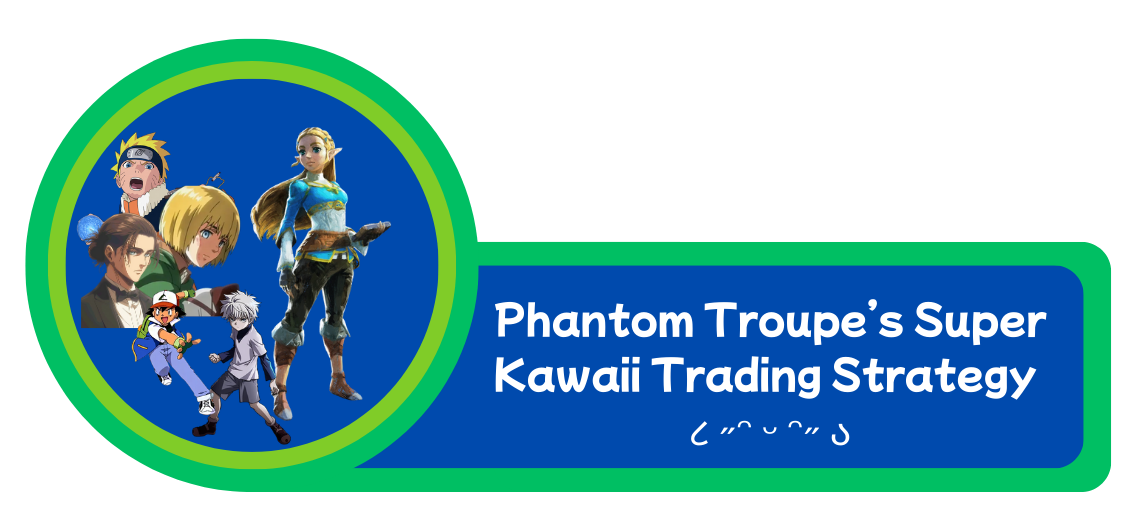

# I. Executive Summary

This study presents our team’s solution for White Stone’s annual forecasting and trading challenge, where competitors are evaluated along two dimensions: forecasting accuracy and portfolio profitability. The central problem of the competition lies in bridging the gap between accurate price forecasting and the construction of a trading strategy that can reliably generate profits. To address this, we focused on three objectives: (1) determining how to allocate the initial capital of $10,000 across selected stocks, (2) developing forecasting models capable of predicting 60-day price movements using only Yahoo Finance data, and (3) converting these forecasts into a systematic trading strategy that performs well during backtesting.

Our methodology follows the constraints and design of the challenge. Using only data from January 1, 2022 to January 1, 2025, we first constructed a static portfolio through Markowitz mean–variance optimization, using historical returns to estimate expected returns and covariances. This provided a long-only, risk-balanced allocation that guided our stock selection. We then evaluated a suite of forecasting models, which includes Random Walk with Drift, Naive, ARIMA, ARIMA–GARCH, VAR, Ridge Regression, Random Forest, Gradient Boosting, and XGBoost, using validation metrics such as MAE, MSE, RMSE, MAPE, SMAPE, and directional accuracy. After identifying the best-performing models per stock, we retrained them on a consolidated training window and produced 60-day recursive forecasts for the test period. These forecasts were incorporated into a second Markowitz optimization, creating a forward-looking portfolio allocation informed by predicted returns.

The final strategy concentrated primarily on NVDA and MPC, reflecting their dominant risk–return trade-offs. Random Forest emerged as the strongest model for NVDA, achieving an MSE of 0.00052 and a SMAPE of 1.64%, while ARIMA(0,1,0) best captured MPC’s stable behavior with an MSE of 0.00031 and a SMAPE of 1.15%. Because both models operate on log-transformed prices, MSE values appear small, so percentage-based metrics were used to provide clearer interpretability.

When executed through backtesting, the Dynamic Markowitz strategy demonstrated the best risk-adjusted performance among the three portfolio strategies evaluated. While its raw return was lower than the Equal Weight approach, the Dynamic Markowitz portfolio achieved the highest Sharpe ratio at 0.1513, indicating superior efficiency when accounting for volatility and drawdowns.

Overall, this work highlights the value of integrating mean–variance optimization with model-driven forecasting to create portfolios that are both forward-looking and risk-conscious. The combination of tailored forecasting models and disciplined portfolio construction provides a practical framework for developing trading strategies that adapt to market dynamics while maintaining robustness under real-world constraints.

# II. Introduction

We are participating in White Stone’s annual forecasting and trading challenge. For this competition, the core difficulty lies in the fact that an accurate forecasting model does not automatically guarantee a profitable trading strategy. Because of this, the competition evaluates competitors on two separate dimensions. Namely, they are forecasting accuracy and portfolio profitability. 

With these constraints, we identify the main problem of the case as a to how we can accurately forecast and then use those forecasts to build a portfolio and trading strategy that maximizes profits? To tackle this, we outline three objectives:

Portfolio Construction and Capital Allocation: To determine how our team should allocate the starting capital of $10,000 across selected stocks.
Forecasting Model Development: To design a forecasting model that maximizes predictive accuracy for 60-day price movements using only Yahoo Finance data.
Strategy Design for Profit Maximization: To convert forecasts into a systematic trading strategy that is profitable during backtesting.

Based on these objectives, we ask the following guiding questions:
1. **Portfolio Construction and Capital Allocation:**
    - What is the most appropriate way to allocate our $10,000 starting capital?
2. **Forecasting Model Development**
    - Which forecasting model is likely to achieve the highest accuracy for our 60-day prediction task?
    - Which accuracy metrics (RMSE, MAPE, directional accuracy, or a combination) should we rely on?
3. **Strategy Design for Profit Maximization**
    - How can we transform our forecasts into a systematic and profitable trading strategy that performs well during backtesting?
    - Does our strategy generate consistent profits across the randomly selected post–January 2025 60-day periods?


# III. Super Kawaii Trading Strategy Overview

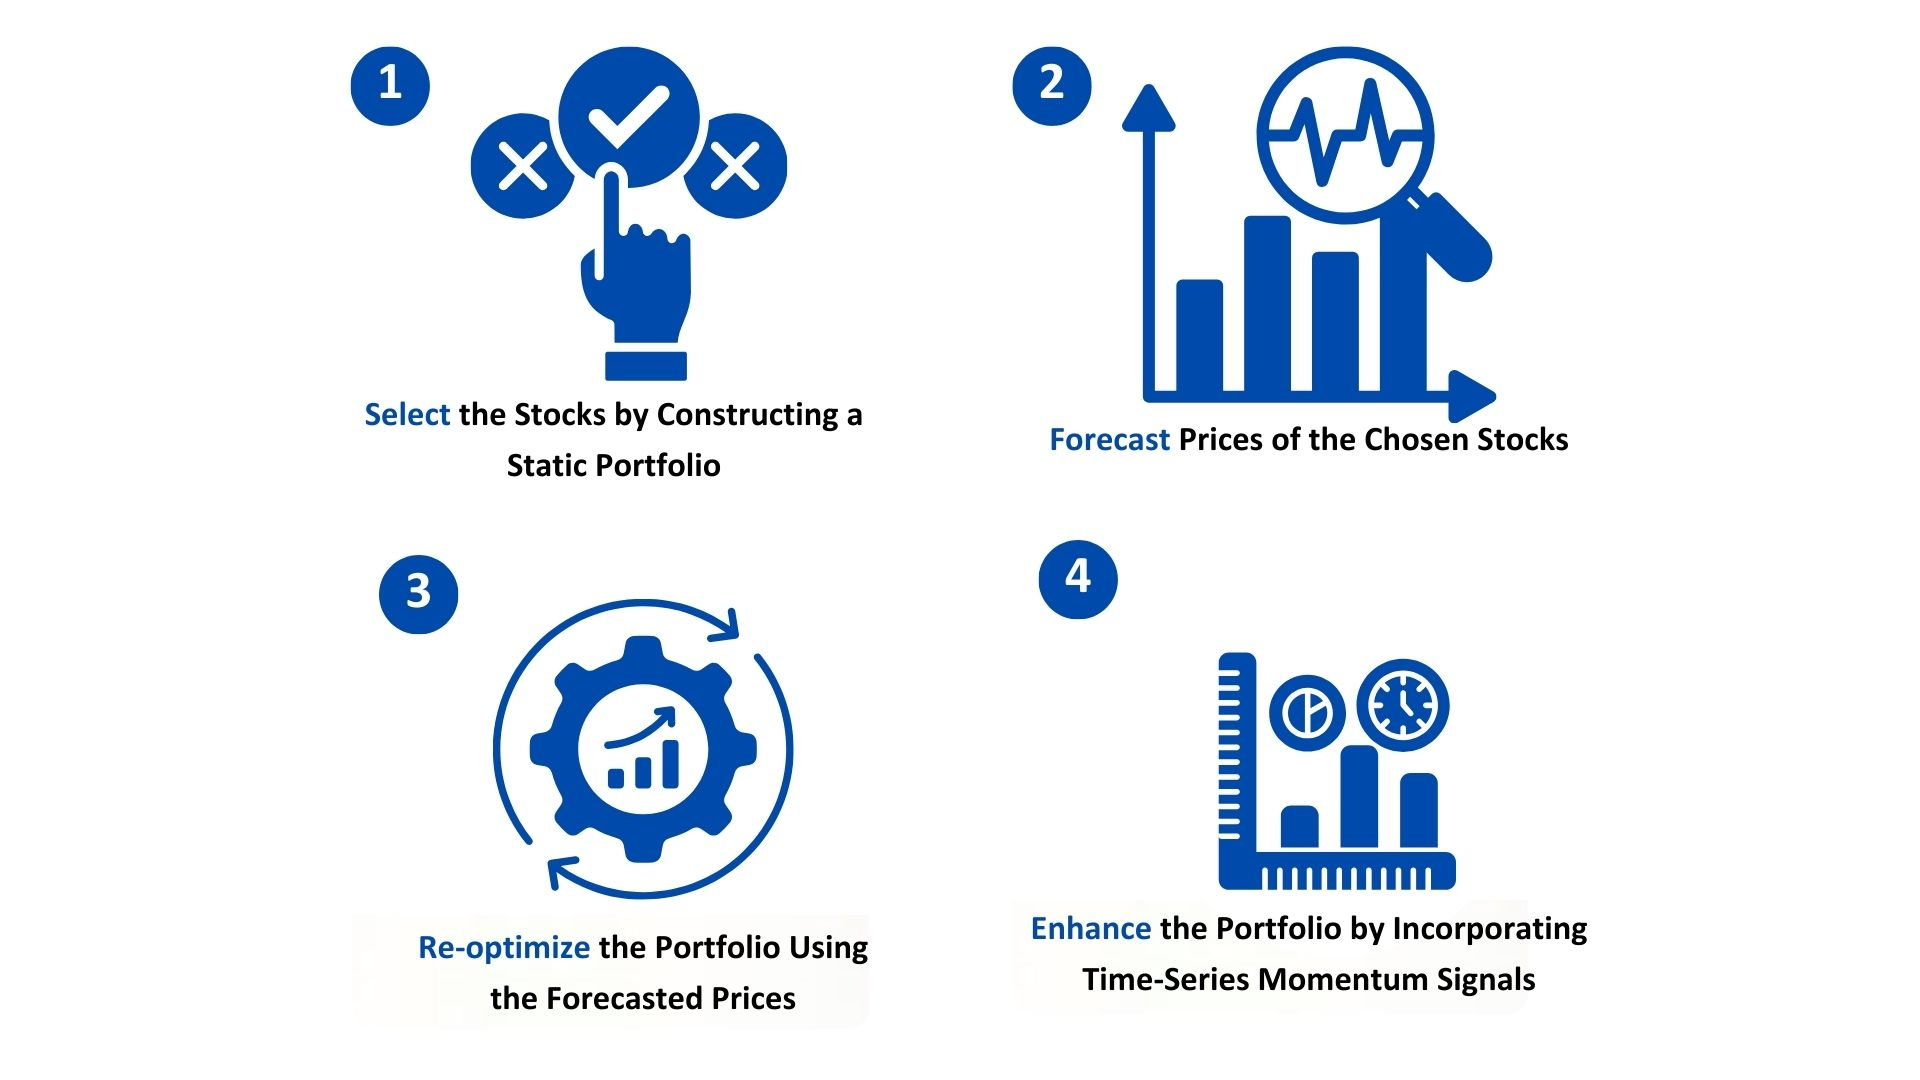

**Figure 1.** Super Kawaii Trading Strategy Overview

For the trading strategy, we hold these as key assumptions based on the trading competition. First, we are provided with $10,000 in starting capital, a transaction cost of 0.1%, and a risk-free rate of 2%. Second, all data must be sourced exclusively from Yahoo Finance, and the training period is limited to January 1, 2022 to January 1, 2025. After this period, each team must generate a 60-day stock price forecast for a randomly assigned 60-day window. Finally, profitability will be assessed through backtesting on that unseen period.

From here, we select the stocks by constructing a static portfolio. The initial Markowitz mean–variance optimization is carried out only on the training portion, using historical returns to estimate expected returns and the covariance matrix. This provides an initial long-only allocation that balances return and risk, forming the baseline portfolio from which the rest of the strategy builds.

For the forecasting stage, we used baseline and machine learning models such as Random Walk with Drift, VAR, Ridge Regression, Linear Regression, Naive, ARIMA and ARIMA-GARCH, Random Forest, Gradient Boosting, XGBoost, and Seasonal Naive methods. Each model is trained on the training split and then its forecasts are evaluated on the validation split using MAE, MSE, RMSE, MAPE, SMAPE, and directional accuracy. The validation performance guides hyperparameter tuning.

Once the best hyperparameters are selected for each possible model, we merge the training and validation sets into a *consolidated-train”* dataset. Using the optimal hyperparameters, each model is retrained on this consolidated-train and then evaluated on the test split to obtain a final unbiased check of out-of-sample performance. For the forecasting stage, we generate multi-step predictions using a recursive approach, where each forecasted value is fed back into the model to produce the next step. After producing the full 60-day recursive forecast, we evaluate model performance on the test split to obtain a final, unbiased assessment of out-of-sample accuracy.

After producing the 60-day forecasts, we re-optimize the portfolio using these predicted returns. In this step, the Markowitz framework is run a second time, but the expected returns are appended with our model-based forecasts. This creates a forward-looking allocation that incorporates the directional information contained in the forecasting models.

# IV. Select the Stocks by Constructing a Static Portfolio

In selecting stocks, we utilize Modern Portfolio Theory (MPT) as developed by Harry Markowitz. We acted as rational investors wherein we wanted to minimize risk while maximizing returns. As such let us formally set up MPT where we will be using the steps as provided by Ślusarczyk and Ślepaczuk (2025). The key idea is that a rational investor with a fixed amount of capital (such as 1000 USD in our case) should distribute that capital across different stocks in a way that maximizes expected return while minimizing risk.


We represent this distribution using a weight vector $w$, where each component corresponds to the fraction of capital invested in one of the thirty given stocks:
$$
w =
\begin{bmatrix}
w_{1}\\
\vdots \\
w_{30}
\end{bmatrix},
$$


Moreover, the weights are constrained by their having to add up to one, so $\sum_{i=1}^{30} w_i = 1$. Also, we restrict the analysis to long-only portfolios by imposing $w_i \geq 0$ for any stock $i$ since the portfolio evaluator is designed only for long positions.
As such, we now formally set up MPT where we will be using the steps as provided by Ślusarczyk and Ślepaczuk (2025) and PyPortfolioOpt, the python module that we are using to get the weights of MPT. Let $r$ be a matrix of T historical daily log returns of n stocks:


Let $r$ be a matrix of T historical daily log returns of n stocks:


$$
r =
\begin{bmatrix}
r_{t-1,1} & \cdots & r_{t-1,n} \\
\vdots & \ddots & \vdots \\
r_{t-T,1} & \cdots & r_{t-T,n}
\end{bmatrix},
$$


where: 
- $T$ is the number of days, so $T=752$ 
- $n$ is number of stocks, so $n$=30
- $r_{t,n}$ is the historical log return for the $n$-th stock for day $t$


Then $\hat{\mu}$ is a vector of means of annualized expected log return:


$$
\hat{\mu} =
\begin{bmatrix}
\hat{\mu}_1 \\
\vdots \\
\hat{\mu}_n
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,1} \\
\vdots \\
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,n}
\end{bmatrix},
$$


and $\hat{\Sigma}$ is the variance-covariance matrix of annualized expected log return:


$$
\hat{\Sigma} =
\begin{bmatrix}
\hat{\sigma}_1^2 & \cdots & \hat{\sigma}_{1,n} \\
\vdots & \ddots & \vdots \\
\hat{\sigma}_{1,n} & \cdots & \hat{\sigma}_n^2
\end{bmatrix},
$$


where $\hat{\sigma}_i^2$ is the empirical variance of historical log returns of the $i$-th stock and $\hat{\sigma}_{i,j}$ is the empirical covariance between historical log returns of the $i$-th and $j$-th stock. These quantities form the sample covariance matrix, which is subsequently passed through the Ledoit–Wolf shrinkage estimator (implemented via `ledoit_wolf`) to obtain a more stable, regularized covariance matrix for portfolio optimization as plotted below in Figure 2.

For the initial Markowitz optimization, we implement a three-way data split of the historical period from January 2022 to January 2025, using a 70–20–10 split into training, validation, and test sets. The Markowitz mean–variance optimization is applied only on the training set, using historical returns to estimate expected returns and the covariance matrix. This ensures that the baseline portfolio is constructed solely from past data, without peeking at the validation or test periods.

As shown in Figure 2, there exists correlations between certains stocks that are generally small as indicated by a blue-colored cell (so near-zero) covariance matrix. This feature is central to Modern Portfolio Theory since it enables portfolio diversification. By selecting stocks that are relatively uncorrelated with one another, we can reduce overall portfolio risk while maintaining expected returns.


In [4]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# ChatGPT made this dictionary
stock_categories = {
    "AAPL": "Technology", "MSFT": "Technology", "NVDA": "Technology",
    "AMZN": "Technology", "GOOGL": "Technology", "META": "Technology", "TSLA": "Technology",
    "JPM": "Finance", "BAC": "Finance", "WFC": "Finance", "C": "Finance", "GS": "Finance", "MS": "Finance",
    "KO": "Consumer Goods", "PG": "Consumer Goods", "PEP": "Consumer Goods",
    "WMT": "Consumer Goods", "COST": "Consumer Goods",
    "CL": "Consumer Goods", "XOM": "Energy", "CVX": "Energy", "COP": "Energy",
    "SLB": "Energy", "EOG": "Energy", "MPC": "Energy",
    "SPY": "ETF", "QQQ": "ETF", "DIA": "ETF", "IWM": "ETF", "VTI": "ETF"
}

# Get the inverse of stock_categories
category_stock = {}
for stock, category in stock_categories.items():
    if category not in category_stock:
        category_stock[category] = []
    category_stock[category].append(stock)
    
# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head(2)

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.270309,170.404495,41.931023,54.393021,76.912796,63.700027,540.298584,101.482430,341.154144,75.843277,...,154.084137,147.359772,392.184082,29.220688,453.210419,399.926666,230.069717,45.828430,45.858696,55.125237
2022-01-04,176.007797,167.522003,43.574478,54.815403,77.167389,66.463234,537.934143,103.328957,343.197266,79.329277,...,154.306778,147.875366,387.097260,30.639345,453.058594,383.196655,229.634140,47.653259,45.018570,57.198723


**Figure 2.** Correlation of Daily Log Returns Across Stocks

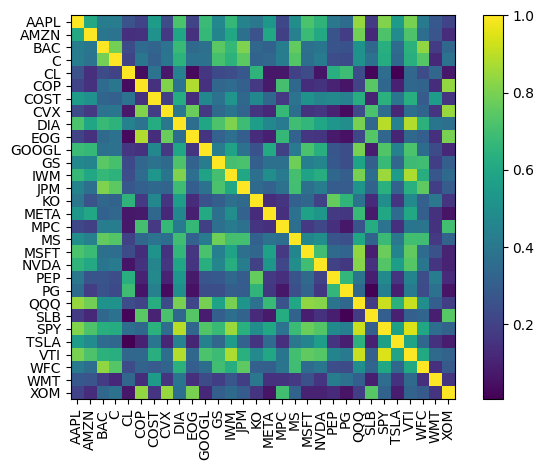

In [5]:
# Total number of rows
n = close_historical_df.shape[0]

# Compute split points
train_end = int(n * 0.7)           # 70% for training

# Create splits but tbh, we only care about the train right now
train_df = close_historical_df.iloc[:train_end]


# mu and Sigma are annualized
mu = mean_historical_return(train_df, log_returns=True)
Sigma = CovarianceShrinkage(train_df, log_returns=True).ledoit_wolf()

plotting.plot_covariance(Sigma, plot_correlation=True)
display(Markdown('**Figure 2.** Correlation of Daily Log Returns Across Stocks'))

From here, we try to maximize the Sharpe Ratio, which is defined as the ratio of the portfolio’s excess return over the risk-free rate to its total risk (standard deviation of returns):
$$\text{Sharpe Ratio} = \frac{\mathbb{E}[R_p] - R_f}{\sigma_p}$$


where $\mathbb{E}[R_p]$ is the expected return of the portfolio, $R_f$ is the risk-free rate, and $\sigma_p$ is the portfolio volatility. The weight vector that achieves the highest Sharpe Ratio is called the tangency portfolio, which  provides the best balance between risk and return. In other words, it gives the most return for each unit of risk taken.


As illustrated in Figure 3, distributing capital across multiple stocks is advantageous because it allows us to exploit the small covariances between assets, thereby reducing overall portfolio risk while maintaining attractive returns. Conversely, investing all capital in a single stock is generally suboptimal because it places the portfolio in the southeast region of the risk-return space, characterized by higher volatility and lower risk-adjusted returns. By diversifying, we effectively move closer to the top-left region of the frontier, where risk is minimized for a given level of expected return.


Figure 3 also highlights the advantage of the tangency portfolio over a simple equal-weighted portfolio. While the tangency portfolio may exhibit slightly higher volatility than an equal-weighted allocation, it achieves a substantially higher return. Even after accounting for this additional volatility by using the Sharpe Ratio, the tangency portfolio remains highly attractive, demonstrating the benefit of optimizing weights rather than allocating equally.


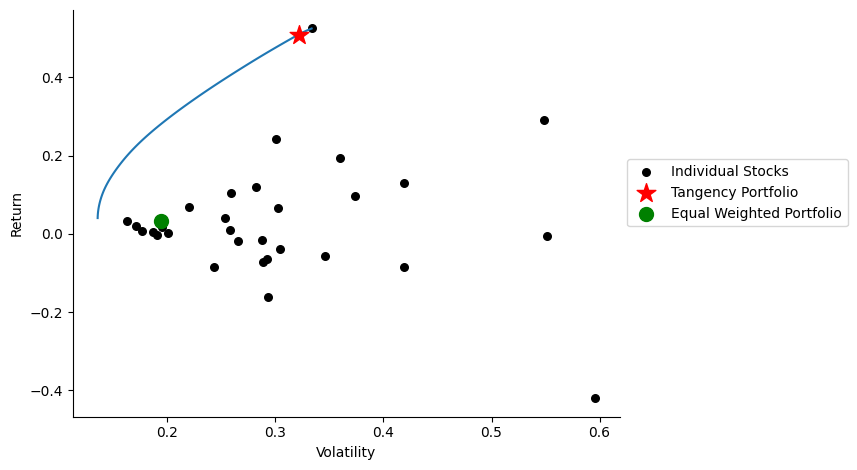

**Figure 3.** Scatterplot of Portfolio Volatility vs Expected Return

In [6]:
# Compute tangency portfolio
ef_tan = EfficientFrontier(mu, Sigma)
tangency_portfolio = ef_tan.max_sharpe(risk_free_rate=0.02)
weights_df = pd.DataFrame(
    [(stock, weight) for stock, weight in ef_tan.clean_weights().items() if weight > 0],
    columns=['Stock', 'Weight']
)

exp_return, vol, sharpe = ef_tan.portfolio_performance(risk_free_rate=0.02)

# Create another EF instance just for plotting
ef_plot = EfficientFrontier(mu, Sigma)
plotting.plot_efficient_frontier(ef_plot, show_assets=True)
plt.scatter(vol, exp_return, marker="*", color="r", s=200, label="Tangency Portfolio", zorder=10)

# plot the equal weighted portfolio
num_stocks = close_historical_df.shape[1]
equal_weight = np.ones(num_stocks) / num_stocks
mu_equal = mu @ equal_weight
sigma_equal = np.sqrt(equal_weight.T @ Sigma @ equal_weight)

plt.scatter(sigma_equal, mu_equal, marker='o', color='green', s=100, label='Equal Weighted Portfolio')
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['Individual Stocks', 'Tangency Portfolio', 'Equal Weighted Portfolio']

plt.legend(handles[1:], labels, loc='upper left', bbox_to_anchor=(1, 0.65))


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

display(Markdown('**Figure 3.** Scatterplot of Portfolio Volatility vs Expected Return'))

From Table 1, we observe that the tangency portfolio assigns a non-zero weight to Marathon Petroleum (MPC) and NVIDIA (NVDA). It is notable that the two stocks come from different sectors, which aligns with the principle of diversification. For instance, movements in the Energy sector are less likely to be strongly correlated with those in Technology, and vice versa. This cross-sector allocation helps reduce overall portfolio risk while maintaining attractive expected returns.


In [7]:
weights_df['Sector'] = weights_df['Stock'].map(stock_categories)
display(weights_df[['Stock', 'Sector', 'Weight']])
display(Markdown('**Table 1.** Stock and Allocated Weight in the Tangency Portfolio'))

,Stock,Sector,Weight
0,MPC,Energy,0.93425
1,NVDA,Technology,0.06575


**Table 1.** Stock and Allocated Weight in the Tangency Portfolio

# V. Forecast Log Prices

## a. Baselines

From Figure 4, raw prices across the two stocks are highly variable and generally exhibit a strong upward trend. Thus, we applied a log transformation to stabilize the variance and allow for easier comparison across stocks. Additionally, since our Markowitz framework relies on log returns, applying the log transformation is consistent with our methodology and ensures the returns are appropriately scaled for subsequent analysis. Log returns have a useful mathematical property since they are simply the difference of consecutive log prices whereas arithmetic returns require dividing the price difference by the previous price. To see this, we start from the definition of the arithmetic return $a_t$ of a stock, where $P_t$ is the price at time $t$ and $P_{t-1}$ is the price at the previous time step:

$$
a_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Adding 1 to both sides:

$$
1 + a_t = \frac{P_t}{P_{t-1}}
$$

Taking the natural logarithm of both sides:

$$
\ln(1 + a_t) = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

Using the logarithm identity $\ln(x/y) = \ln(x) - \ln(y)$:

$$
\ln(1 + a_t) = \ln(P_t) - \ln(P_{t-1})
$$

The right-hand side is the log return $r_t$ at time $t$, which we denote as:

$$
r_t = \ln(P_t) - \ln(P_{t-1})
$$

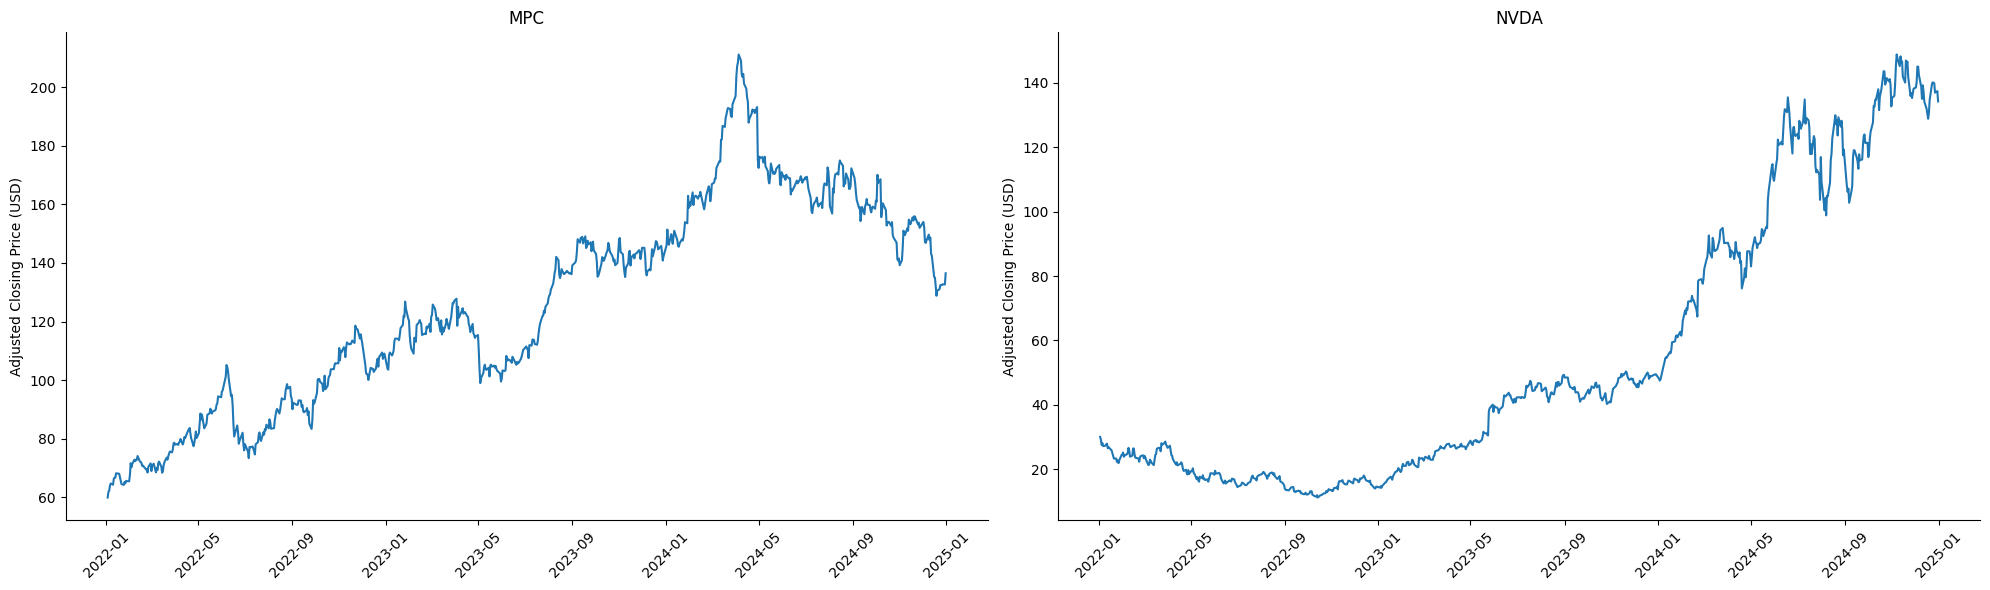

**Figure 4.** USD Prices of the 4 Stocks

In [8]:
# Keep only stocks on non-zero weights
selected_stocks = ["MPC", "NVDA"]
close_historical_df = close_historical_df[selected_stocks]

fig, axs = plt.subplots(1, 2, figsize=(20, 6), sharex=True)

for ax, stock in zip(axs.flatten(), close_historical_df.columns):
    ax.plot(close_historical_df[stock])
    ax.set_title(stock)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Adjusted Closing Price (USD)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

display(Markdown("**Figure 4.** USD Prices of the 4 Stocks"))

To construct the baseline models (mean, naive, and seasonal naive) in a single figure, we first assessed whether seasonality was present across the stocks. As shown in Figure 5, there is no consistent or systematic seasonal pattern observable across the full set of assets. Given this inconsistency, we proceed by assuming a simplified seasonality of 20 business days (a month) for the baseline seasonal naive model.

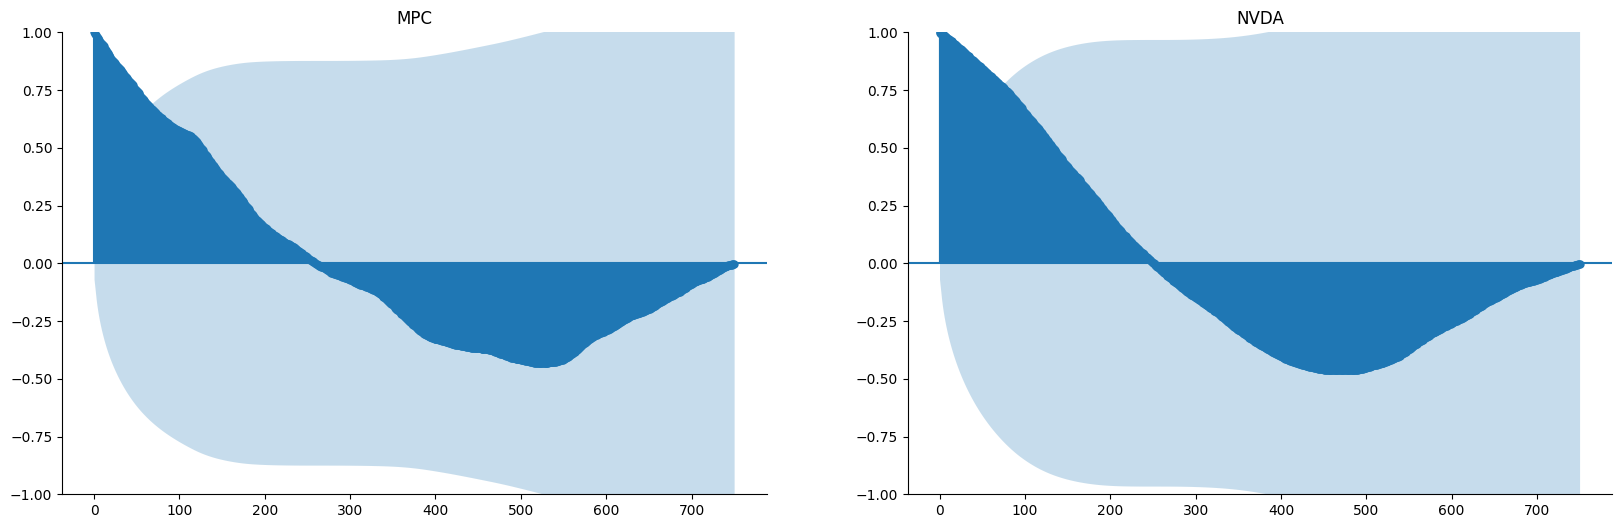

**Figure 5.** ACF of the 2 Stocks

In [9]:
# Apply log
close_log_df = np.log(close_historical_df)

fig, axs = plt.subplots(1, 2, figsize=(20, 6), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df.columns):
    plot_acf(close_log_df[stock], ax=ax, lags=750, title=stock)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.show()

display(Markdown("**Figure 5.** ACF of the 2 Stocks"))

As aforementioned, we implement a three-way data split into training, validation, and test sets, covering the period from January 2022 to January 2025, using a 70–20–10 split. The training set is used to estimate historical returns and covariances for the initial Markowitz portfolio and to fit our forecasting models. The validation set is reserved for hyperparameter tuning, allowing us to evaluate and select the best model configurations without peeking at the final performance. Finally, the test set serves as an out-of-sample evaluation set, providing a final unbiased assessment of model forecasts and portfolio performance after retraining on the combined training and validation data.


In [10]:
# Total number of rows
n = close_log_df.shape[0]

# Compute split points
train_end = int(n * 0.7)           # 70% for training
val_end = train_end + int(n * 0.2) # next 20% for validation

# Create splits
train_df = close_log_df.iloc[:train_end]
val_df = close_log_df.iloc[train_end:val_end]
test_df = close_log_df.iloc[val_end:]

print(f"Training set: {train_df.shape[0]} rows ({train_df.shape[0]/n:.0%})")
print(f"Validation set: {val_df.shape[0]} rows ({val_df.shape[0]/n:.0%})")
print(f"Test set: {test_df.shape[0]} rows ({test_df.shape[0]/n:.0%})")


Training set: 527 rows (70%)
Validation set: 150 rows (20%)
Test set: 76 rows (10%)


In [11]:
def forecast_seasonal_naive(df: pd.DataFrame, m: int = 5, horizon: int = None) -> pd.DataFrame:
    """
    Seasonal naïve forecasting model applied column-wise to a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame where each column represents a univariate time series
        (e.g., multiple stock price series).
    m : int, optional (default=5)
        The assumed seasonality length. The model uses the last `m` observations
        of each column as the repeating seasonal pattern.
    horizon : int, optional
        Number of future time steps to forecast. If None, uses length of df.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing seasonal naïve forecasts for each column of `df`.
        Each column contains `horizon` forecasts derived from the last `m` values.
    """
    if horizon is None:
        horizon = len(df)

    forecasts = {}
    for col in df.columns:
        last_m_vals = df[col].iloc[-m:].values.ravel()
        repeated_vals = np.tile(last_m_vals, horizon)[:horizon]
        forecasts[col] = repeated_vals

    return pd.DataFrame(forecasts)


In [12]:
horizon = val_df.shape[0]  # number of rows to forecast

# Mean forecast
mean_forecast = pd.DataFrame([train_df.mean().values] * horizon,
                             index=val_df.index,
                             columns=val_df.columns)

# Naive forecast (last value)
naive_forecast = pd.DataFrame([train_df.iloc[-1].values] * horizon,
                              index=val_df.index,
                              columns=val_df.columns)

# Seasonal naive forecast
seasonal_naive_forecast = forecast_seasonal_naive(train_df, m=20, horizon=horizon)
seasonal_naive_forecast.index = val_df.index


From Figure 6, we plotted the log prices of the two stocks, with the top line representing MPC and the bottom line representing NVDA. Among the three baseline models, the naive forecast performs best on the validation set, capturing the general movement of the log prices more accurately than the mean or seasonal naive forecasts.

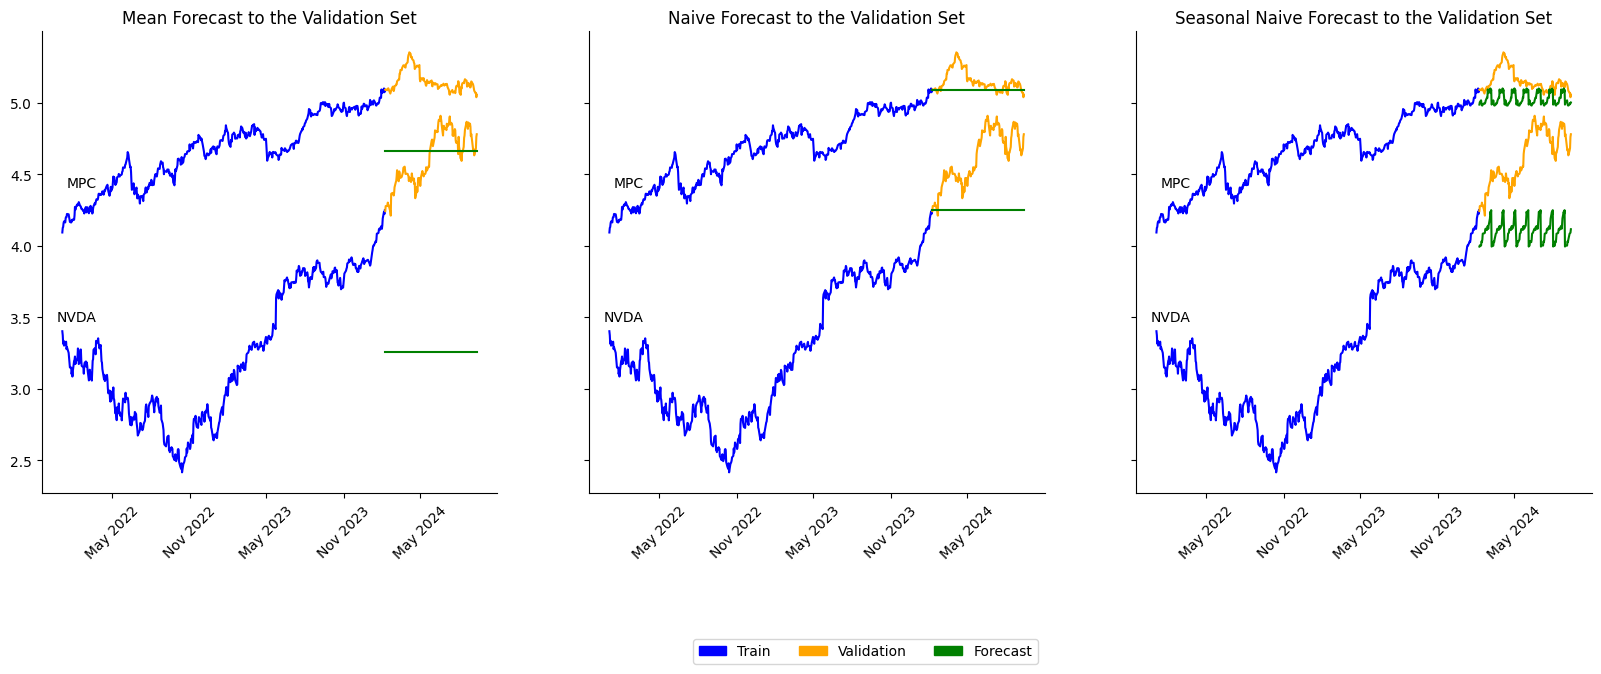

**Figure 6.** Baseline Forecasts of Log Prices Across Stocks

In [13]:
# Drawing time!
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

opacity_num = 1
for ax in axs:
    ax.plot(train_df, color='blue', alpha=opacity_num)

    ax.plot(val_df, color='orange', alpha=opacity_num)

# Plot the mean
axs[0].plot(mean_forecast, label='Mean Forecast', color='green', alpha=opacity_num)
axs[0].set_title('Mean Forecast to the Validation Set')

# plot the naive
axs[1].plot(naive_forecast, label='Naive Forecast', color='green', alpha=opacity_num)
axs[1].set_title('Naive Forecast to the Validation Set')

# plot the Seasonal Naive
axs[2].plot(seasonal_naive_forecast, label='Seasonal Naive Forecast', color='green', alpha=opacity_num)
axs[2].set_title('Seasonal Naive Forecast to the Validation Set')

# Prettier x-axis
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # major ticks each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as 'Jan 2025'
    ax.tick_params(axis='x', rotation=45)  # rotate labels
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', bbox_to_anchor=(-0.2, -0.3), ncol=3)

# Add text labels inside each subplot for top and bottom lines
for ax in axs:
    # Get the last x position for placing labels
    x_pos = ax.get_xlim()[1] * 0.9525 # near the right edge
    # Top line (MPC)
    y_pos_top = train_df.iloc[-1, 0] - 0.7  # adjust column if needed
    ax.text(x_pos, y_pos_top, 'MPC', color='black', fontsize=10, ha='right', va='bottom')
    # Bottom line (NVDA)
    y_pos_bottom = train_df.iloc[-1, 1] - 0.7  # adjust column if needed
    ax.text(x_pos, y_pos_bottom, 'NVDA', color='black', fontsize=10, ha='right', va='top')



plt.show()

display(Markdown("**Figure 6.** Baseline Forecasts of Log Prices Across Stocks"))


In [14]:
# Dictionary to store all metrics
performance_stock = {}

for stock in val_df.columns:
    # Compute metrics for each baseline
    performance_stock[stock] = {
        'Mean': ForecastingMetrics.compute_all_metrics(val_df[stock], mean_forecast[stock]),
        'Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], naive_forecast[stock]),
        'Seasonal Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], seasonal_naive_forecast[stock])
    }

In [15]:
def performance_dict_to_df(performance_stock_dict):
    """
    Converts a nested dictionary of performance metrics into a multi-index DataFrame.
    
    Parameters
    ----------
    performance_stock_dict : dict
        Nested dict of the form {stock: {model_name: {metric_name: value, ...}, ...}, ...}
    
    Returns
    -------
    pd.DataFrame
        MultiIndex DataFrame with index ['Stock', 'Model'] and metric columns.
    """
    df_list = []

    for stock, metrics_per_model in performance_stock_dict.items():
        for model, metrics in metrics_per_model.items():
            row = metrics.copy()
            row['Stock'] = stock
            row['Model'] = model
            df_list.append(row)
    
    metrics_df = pd.DataFrame(df_list).set_index(['Stock', 'Model'])
    return metrics_df

#performance_dict_to_df(performance_stock)


## b. ARIMA

The first step in constructing an ARIMA model is to assess the stationarity of the log price time series using the Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) tests. We applied both tests across all stocks, recording the results in Table 2. For the four stocks, none of them passed both tests, so they were considered non-stationary and were thus differenced to get the stock's log returns.

In [16]:
warnings.filterwarnings("ignore")

# --- ADF Test Function ---
def adf_test_suite(timeseries):
    """
    Performs the Augmented Dickey-Fuller test on a time series.
    H0: The series is non-stationary.
    """
    # Use 'ct' for constant and trend since visual inspection (Figure 2) shows a clear trend
    result = adfuller(timeseries, autolag='AIC', regression='ct')
    
    p_value = result[1]
    
    # Check p-value against a 5% significance level (alpha=0.05)
    is_stationary = 'Stationary' if p_value <= 0.05 else 'Non-Stationary'
    
    return pd.Series({
        'ADF Statistic': result[0],
        'ADF P-value': p_value,
        'ADF Lags Used': result[2],
        'ADF Conclusion (alpha=0.05)': is_stationary
    })

# --- KPSS Test Function ---
def kpss_test_suite(timeseries):
    """
    Performs the Kwiatkowski-Phillips-Schmidt-Shin test on a time series.
    H0: The series is trend-stationary.
    """
    # Use 'ct' for trend-stationarity (constant and trend)
    result = kpss(timeseries, regression='ct', nlags='auto')
    
    p_value = result[1]
    
    # Check p-value against a 5% significance level (alpha=0.05)
    is_stationary = 'Stationary' if p_value > 0.05 else 'Non-Stationary'
    
    return pd.Series({
        'KPSS Statistic': result[0],
        'KPSS P-value': p_value,
        'KPSS Lags Used': result[2],
        'KPSS Conclusion (alpha=0.05)': is_stationary
    })

In [17]:
adf_results_df = close_log_df.apply(adf_test_suite, axis=0).T
kpss_results_df = close_log_df.apply(kpss_test_suite, axis=0).T

final_results = pd.DataFrame({
    'ADF Conclusion': adf_results_df['ADF Conclusion (alpha=0.05)'],
    'KPSS Conclusion': kpss_results_df['KPSS Conclusion (alpha=0.05)']
})

def consolidate_conclusion(row):
    """Consolidate stationarity conclusions from ADF and KPSS tests for a time series."""
    adf_c = row['ADF Conclusion']
    kpss_c = row['KPSS Conclusion']
    
    if adf_c == 'Stationary' and kpss_c == 'Stationary':
        return 'Strictly Stationary (Strong Evidence)'
    elif adf_c == 'Non-Stationary' and kpss_c == 'Non-Stationary':
        return 'Non-Stationary (Strong Evidence)'
    elif adf_c == 'Stationary' and kpss_c == 'Non-Stationary':
        # ADF rejects Unit Root, KPSS rejects Trend-Stationary. Contradictory.
        # Often implies the series is difference stationary (needs differencing).
        return 'Difference Stationary (Requires Differencing)'
    elif adf_c == 'Non-Stationary' and kpss_c == 'Stationary':
        # ADF fails to reject Unit Root, KPSS fails to reject Trend-Stationary.
        # Often implies the series is trend stationary (needs detrending).
        return 'Trend Stationary (Requires Detrending)'
    else:
        return 'Inconclusive/Contradictory'

final_results['Consolidated Conclusion'] = final_results.apply(consolidate_conclusion, axis=1)
display(final_results)

display(Markdown("**Table 2.** ADF and KPSS Conclusions on the Log Prices"))


,ADF Conclusion,KPSS Conclusion,Consolidated Conclusion
Ticker,,,
MPC,Non-Stationary,Non-Stationary,Non-Stationary (Strong Evidence)
NVDA,Non-Stationary,Non-Stationary,Non-Stationary (Strong Evidence)


**Table 2.** ADF and KPSS Conclusions on the Log Prices

As shown in Table 3, all series are stationary according to the ADF test. However, NVDA may still require differencing, as the KPSS test indicates non-stationarity. To confirm, we can first examine NVDA’s log returns visually to assess whether the series exhibits stationarity.

In [18]:
# Difference only once
close_log_df1 = close_log_df.diff().dropna()

adf_results_df = close_log_df1.apply(adf_test_suite, axis=0).T
kpss_results_df = close_log_df1.apply(kpss_test_suite, axis=0).T

final_results = pd.DataFrame({
    'ADF Conclusion': adf_results_df['ADF Conclusion (alpha=0.05)'],
    'KPSS Conclusion': kpss_results_df['KPSS Conclusion (alpha=0.05)']
})

final_results['Consolidated Conclusion'] = final_results.apply(consolidate_conclusion, axis=1)
display(final_results)

display(Markdown("**Table 3.** ADF and KPSS Conclusions on the Log Returns"))

,ADF Conclusion,KPSS Conclusion,Consolidated Conclusion
Ticker,,,
MPC,Stationary,Stationary,Strictly Stationary (Strong Evidence)
NVDA,Stationary,Non-Stationary,Difference Stationary (Requires Differencing)


**Table 3.** ADF and KPSS Conclusions on the Log Returns

Figure 7 indicates that the first-order differences of the log prices already exhibit stationarity. Additionally, financial theory, particularly within the context of Modern Portfolio Theory (MPT), supports the use of log returns (i.e., the first difference of log prices) for modeling, while further differencing may introduce unnecessary noise. Therefore, the optimal order of differencing $d$ is set to 1.

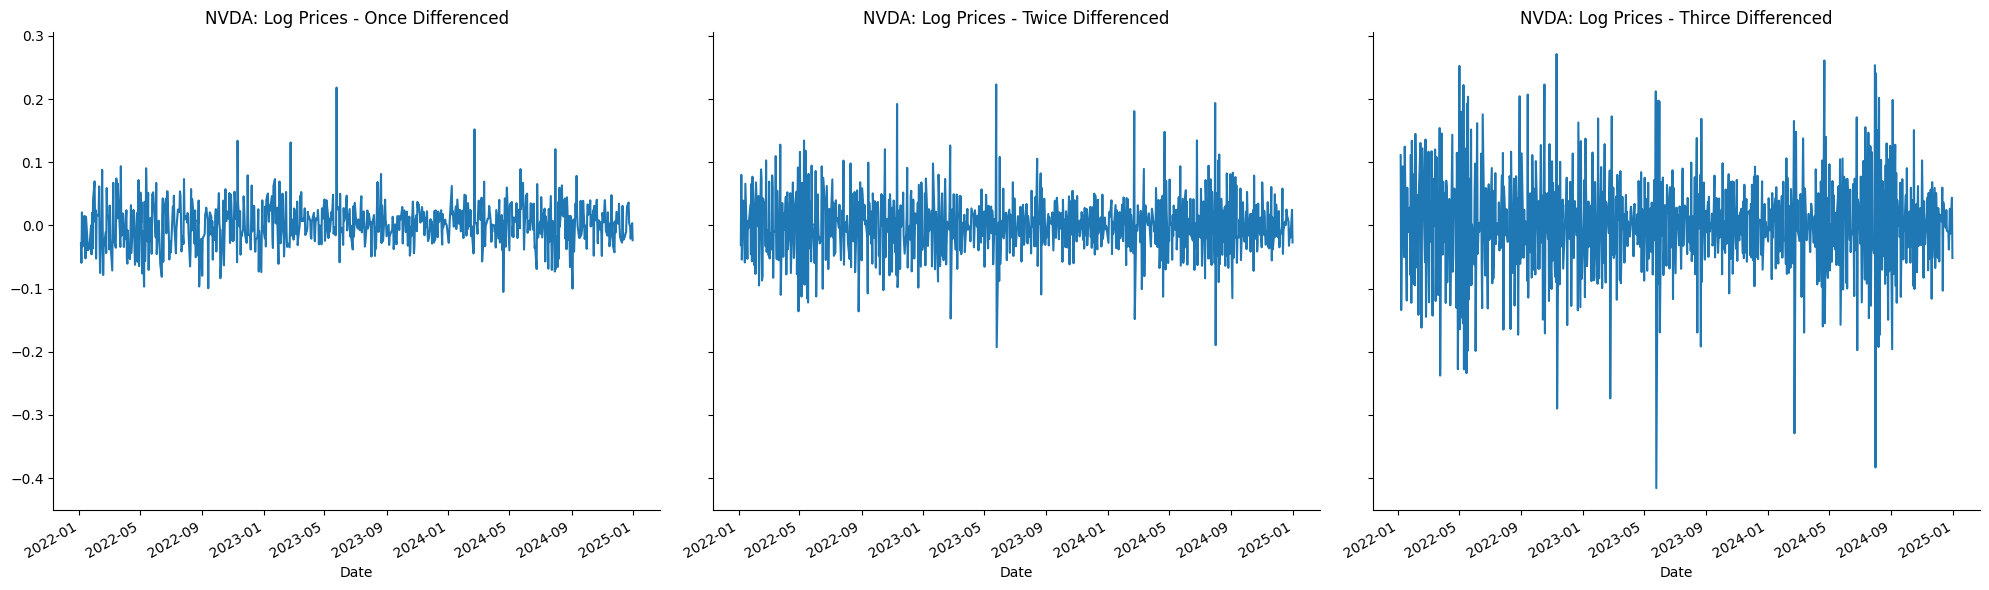

**Figure 7.** Differencing of NVDA Log Prices

In [19]:
# Plot the differenced series
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
focused_stock = 'NVDA'

# Original log returns
close_log_df1[stock].plot(ax=axes[0], title=f'{focused_stock}: Log Prices - Once Differenced')
# 2nd difference
close_log_df1[stock].diff().plot(ax=axes[1], title=f'{focused_stock}: Log Prices - Twice Differenced')
# 3rd difference
close_log_df1[stock].diff().diff().plot(ax=axes[2], title=f'{focused_stock}: Log Prices - Thirce Differenced')

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
plt.tight_layout()
plt.show()

display(Markdown("**Figure 7.** Differencing of NVDA Log Prices"))

From Figure 8, all stocks exhibit minimal autocorrelation after first-order differencing, indicating that past values do not significantly predict future values. Consequently, the optimal autoregressive order $p$ is set to 0.

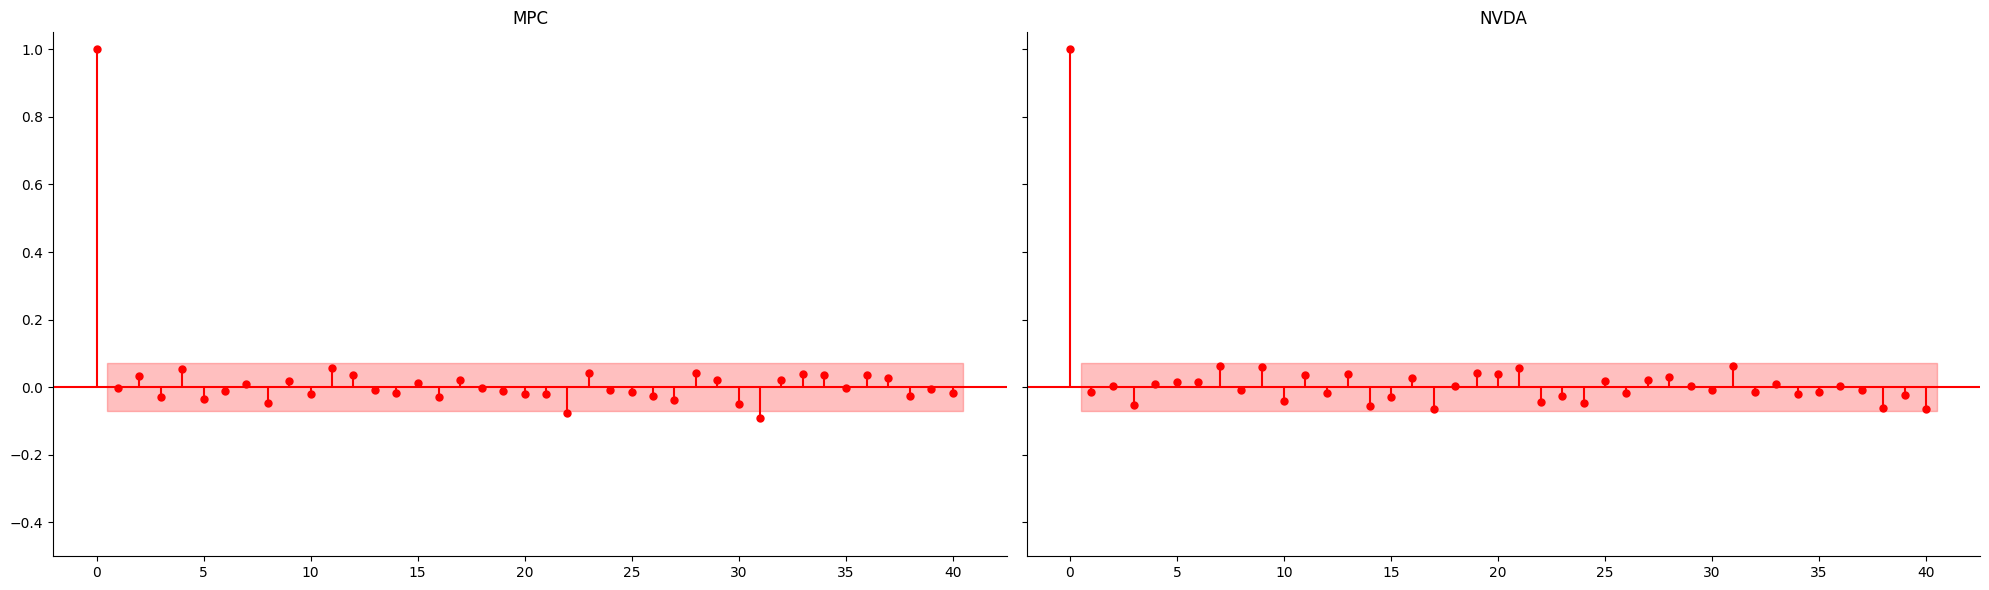

**Figure 8.** PACF of the Differenced Log Prices Across the Four Stocks

In [20]:
# Assuming close_log_df1 is your differenced data
fig, axs = plt.subplots(1, 2, figsize=(20, 6), sharex=True, sharey=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    # Plot PACF
    plot_pacf(close_log_df1[stock].dropna(), ax=ax, lags=40, method='ywm')
    ax.set_title(stock)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-0.5, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for item in ax.collections:
        item.set_color('red')
    for item in ax.lines:
        item.set_color('red')


# Add main title
#fig.suptitle('PACF of the Differenced 30 Stocks', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

display(Markdown("**Figure 8.** PACF of the Differenced Log Prices Across the Four Stocks"))

As shown in Figure 9, most stocks exhibit minimal autocorrelation after first-order differencing, suggesting limited moving average effects. Consequently, the optimal moving average order $q$ is set to 0.

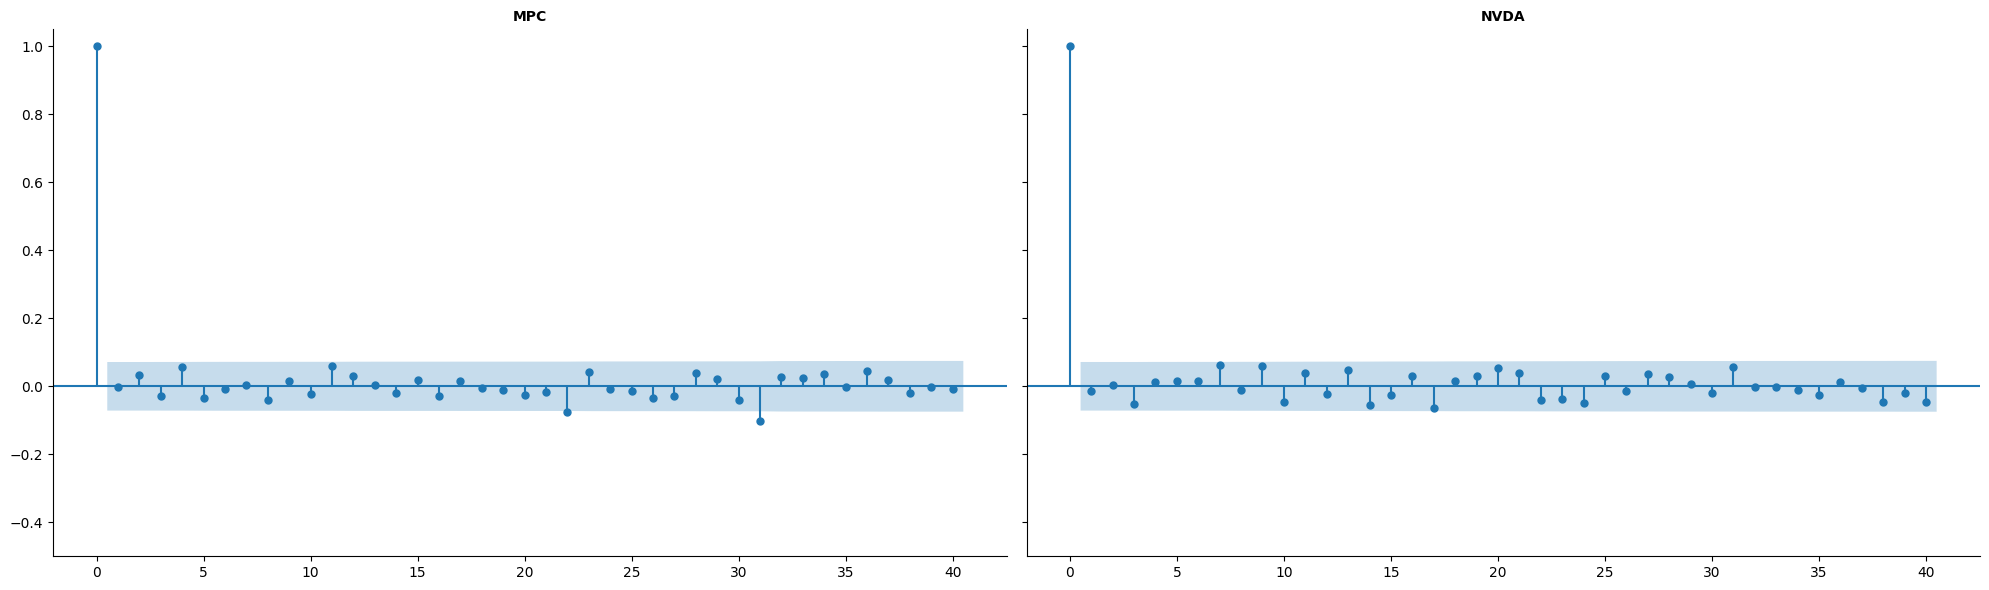

**Figure 9.** ACF of the Differenced Log Prices Across the Four Stocks

In [21]:
# Assuming close_log_df1 is your differenced data
fig, axs = plt.subplots(1, 2, figsize=(20, 6), sharex=True, sharey=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    # Plot ACF
    plot_acf(close_log_df1[stock].dropna(), ax=ax, lags=40)
    ax.set_title(stock, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-0.5, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add main title
#fig.suptitle('ACF of the Differenced 4 Stocks', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


display(Markdown("**Figure 9.** ACF of the Differenced Log Prices Across the Four Stocks"))

As a sanity check, we evaluated all combinations of $p$ and $q$ from 0 to 4 while keeping $d = 1$ fixed. Using the Bayesian Information Criterion (BIC) as the model selection metric, we identified the optimal $(p, q)$ in Table 4 pair for each stock, where lower BIC values indicate a better fit. This additional validation step confirmed our earlier findings that the simplest specification, ARIMA(0, 1, 0), consistently performed best across the four stocks. This reinforces the conclusion that a random-walk structure with no autoregressive or moving-average components is the most appropriate model for these log price series.

In [22]:
# Store results for all stocks
all_results = []

# Test different orders for each stock
for stock in close_log_df.columns:
    results = {}
    
    for p in range(0, 4):
        for q in range(0, 4):
            try:
                model = ARIMA(train_df[stock], order=(p, 1, q))
                fitted = model.fit()
                results[(p, q)] = fitted.bic
            except Exception as e:
                # Skip models that fail to converge
                continue
    
    # Check if any models succeeded
    if len(results) > 0:
        best_model = min(results, key=results.get)
        all_results.append({
            'Stock': stock,
            'Optimal p': best_model[0],
            'Optimal q': best_model[1],
            'BIC': results[best_model]
        })
    else:
        all_results.append({
            'Stock': stock,
            'Optimal p': None,
            'Optimal q': None,
            'BIC': None
        })




In [23]:
# Create and display DataFrame
bic_results_df = pd.DataFrame(all_results)

display(bic_results_df)
display(Markdown("**Table 4:** Optimal ARIMA Orders by BIC:"))

,Stock,Optimal p,Optimal q,BIC
0,MPC,0,0,-2559.264195
1,NVDA,0,0,-2034.321785


**Table 4:** Optimal ARIMA Orders by BIC:

We then plotted out in Figure 10 on how ARIMA(0, 1, 0) would actually forecast the log prices, and it forecasted exactly like the naive baseline. In particular, it forecasts future log prices as

$$
\ln P_{t} = \ln P_{t-1} + \varepsilon_{t},
$$

where $\varepsilon_{t+1}$ is a white noise term with mean zero. This means that the best point forecast for the next period is simply yesterday’s log price, which is similar to the approach with the naive baseline where it just uses the latest possible log price.


In [24]:
def train_and_forecast_arima(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    bic_results_df: pd.DataFrame,
    horizon: int = None
) -> pd.DataFrame:
    """
    Train ARIMA(p,1,q) models using optimal p and q, then forecast the next horizon steps.
    """

    import warnings
    warnings.filterwarnings("ignore")

    if horizon is None:
        horizon = len(val_df)  # default to validation length

    # Ensure Stock is index
    bic_results_df = bic_results_df.set_index("Stock")

    # Prepare forecast container — same index as validation set
    arima_forecasts = pd.DataFrame(index=val_df.index, columns=val_df.columns)

    # Iterate through each stock
    for stock in train_df.columns:

        # Check if stock has BIC results
        if stock not in bic_results_df.index:
            print(f"Warning: No optimal orders found for {stock}. Skipping.")
            arima_forecasts[stock] = np.nan
            continue

        try:
            # Extract optimal p, q (ensure INT)
            p = int(bic_results_df.loc[stock, "Optimal p"])
            q = int(bic_results_df.loc[stock, "Optimal q"])
            order = (p, 1, q)

            # Fit ARIMA
            model = ARIMA(train_df[stock], order=order).fit()

            # Generate forecast
            forecast_obj = model.get_forecast(steps=horizon)
            forecast = forecast_obj.predicted_mean

            # Align forecast index to validation index
            forecast.index = val_df.index

            # Store
            arima_forecasts[stock] = forecast

        except Exception as e:
            print(f"Error fitting/forecasting ARIMA for {stock}: {e}")
            arima_forecasts[stock] = np.nan

    return arima_forecasts


In [25]:
# Recursive Forecast time
arima_forecasts_df = train_and_forecast_arima(
    train_df, 
    val_df, 
    bic_results_df, 
    horizon=val_df.shape[0]
)

# Add it to the performance_stock dictionary
for stock in selected_stocks:
    performance_stock[stock]['ARIMA(0, 1, 0)'] = ForecastingMetrics.compute_all_metrics(
        val_df[stock], arima_forecasts_df[stock]
    )


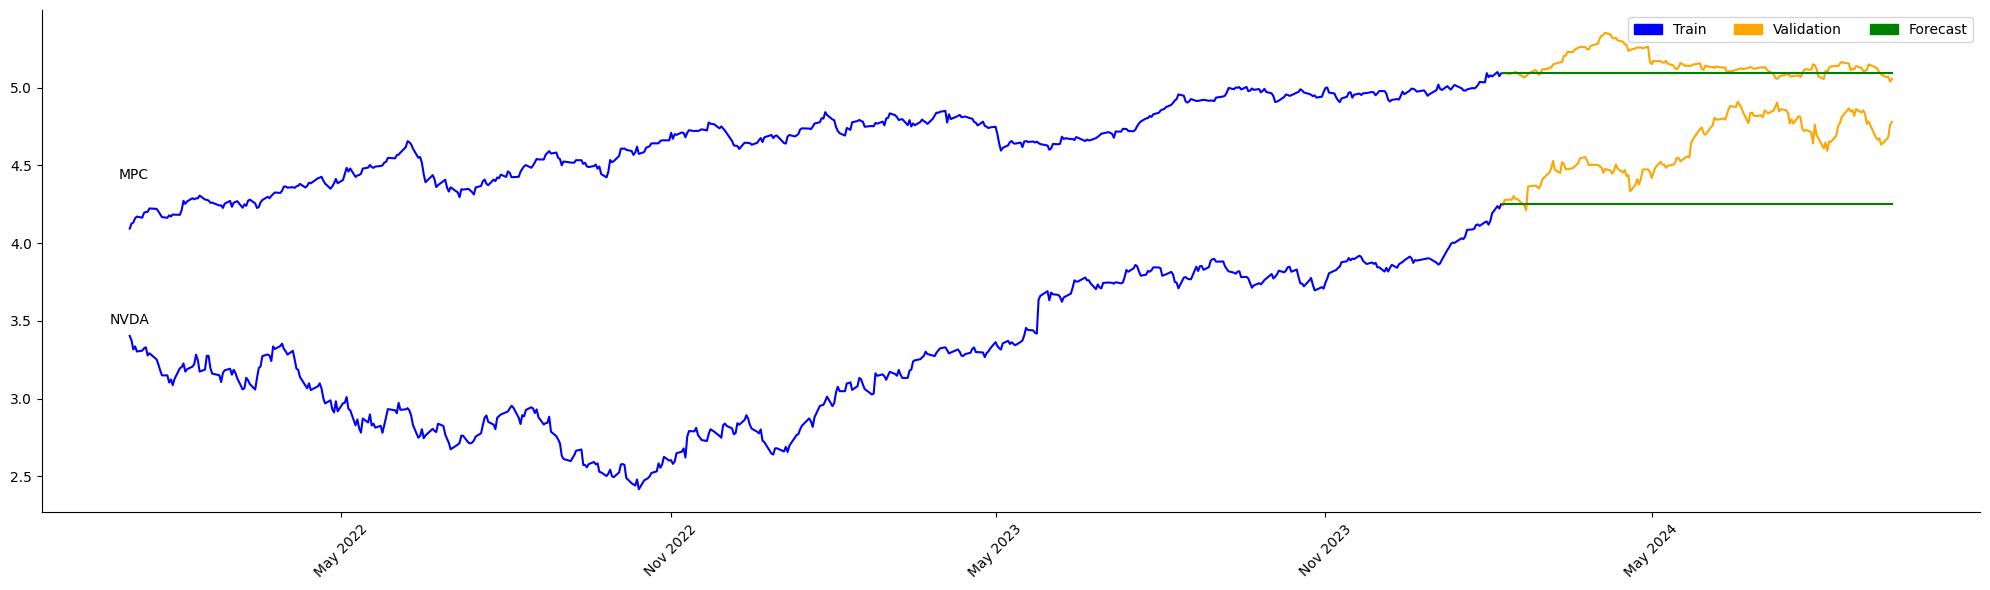

**Figure 10.** ARIMA Forecasts of Log Prices Across Stocks

In [26]:
fig, ax = plt.subplots(figsize=(20, 6))

# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)

# --- ARIMA forecast ---
ax.plot(arima_forecasts_df, color='green', alpha=opacity_num, label='ARIMA Forecast')

#ax.set_title('ARIMA Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', ncol=3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Get the last x position for placing labels
x_pos = ax.get_xlim()[1] * 0.949 # near the right edge
# Top line (MPC)
y_pos_top = train_df.iloc[-1, 0] - 0.7  # adjust column if needed
ax.text(x_pos, y_pos_top, 'MPC', color='black', fontsize=10, ha='right', va='bottom')
# Bottom line (NVDA)
y_pos_bottom = train_df.iloc[-1, 1] - 0.7  # adjust column if needed
ax.text(x_pos, y_pos_bottom, 'NVDA', color='black', fontsize=10, ha='right', va='top')

plt.show()

display(Markdown("**Figure 10.** ARIMA Forecasts of Log Prices Across Stocks"))

## c. Random Walk with Drift

Let us now extend the random walk to include a drift. Assuming there is an underlying growth in stock prices, we take the first difference of the log prices and compute the mean. This yields the mean log return ($\mu$), which can be interpreted as the drift term in the model. We write this down as:
$$\ln P_{t} = \ln P_{t-1} + \mu + \varepsilon_{t}.$$
As shown in Figure 11, this approach better captures the log prices since it follows the upward trend of the stocks.

In [27]:
# Example: train_df is log prices, columns = stocks, rows = dates
forecast_horizon = 150

# 1. Compute mean log return (drift) per stock
drift = train_df.diff().mean(axis=0)  # pandas Series, index = stocks

# 2. Get last log price per stock
last_log_price = train_df.iloc[-1]   # Series, index = stocks

# 3. Create random walk with drift
# For simplicity, here we just add the drift deterministically (no noise)
forecast_log_prices = pd.DataFrame(
    index=val_df.index, 
    columns=train_df.columns,
    dtype=float
)

for stock in train_df.columns:
    # Add drift cumulatively
    forecast_log_prices[stock] = last_log_price[stock] + np.cumsum(np.repeat(drift[stock], forecast_horizon))

# Get the performance
for stock in selected_stocks:
    performance_stock[stock]['Random Wak with Drift'] = ForecastingMetrics.compute_all_metrics(
        val_df[stock], forecast_log_prices[stock]
    )

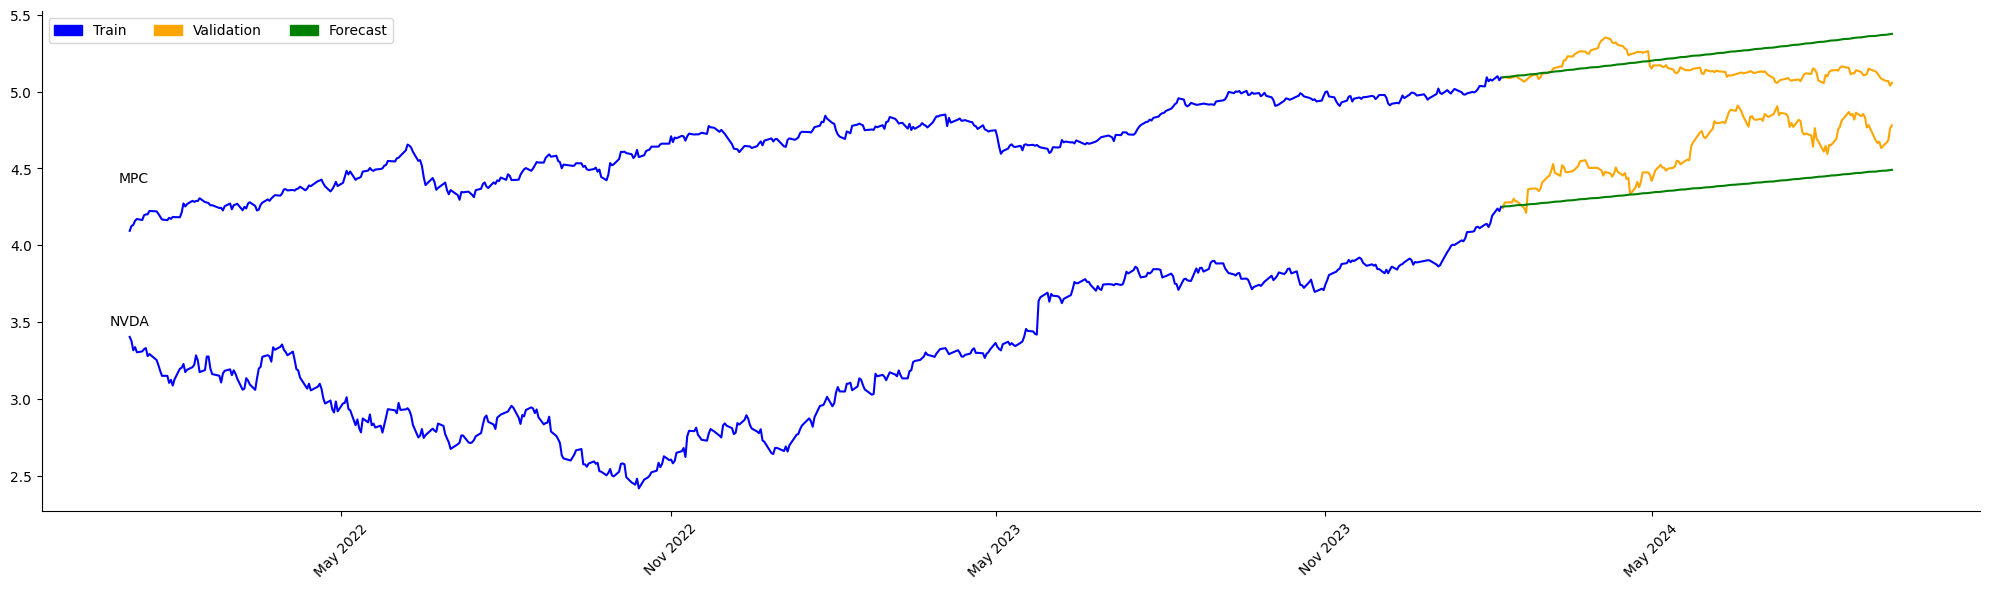

**Figure 11.** Random Walk with Drift Forecasts of Log Prices Across Stocks

In [28]:
fig, ax = plt.subplots(figsize=(20, 6))


# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)

# --- random walk with drift forecast ---
ax.plot(forecast_log_prices, color='green', alpha=opacity_num, label='ARIMA Forecast')

#ax.set_title('Random Walk with Drift Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', ncol=3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Get the last x position for placing labels
x_pos = ax.get_xlim()[1] * 0.949 # near the right edge
# Top line (MPC)
y_pos_top = train_df.iloc[-1, 0] - 0.7  # adjust column if needed
ax.text(x_pos, y_pos_top, 'MPC', color='black', fontsize=10, ha='right', va='bottom')
# Bottom line (NVDA)
y_pos_bottom = train_df.iloc[-1, 1] - 0.7  # adjust column if needed
ax.text(x_pos, y_pos_bottom, 'NVDA', color='black', fontsize=10, ha='right', va='top')

plt.show()

display(Markdown("**Figure 11.** Random Walk with Drift Forecasts of Log Prices Across Stocks"))

## d. ML Models (Ridge and Random Forest)

In addition to the current models we have, we also included standard machine learning models such as Random Forest, XGBoost, Linear Regression, Ridge Regression, and Gradient Boosting. Linear regression was used as a simple, interpretable benchmark for predicting linear relationships between the predictors and returns. Ridge regression extends this by adding regularization to reduce overfitting if features are correlated. Random Forest was selected as its ensemble structure captures nonlinear relationship effects between variables to make it robust to noise and overfitting. Gradient Boosting and XGBoost were included because boosting methods reduce residual errors, achieving high predictive accuracy in settings where patterns are subtle or complex. These models complement the econometric approaches by providing non-linear estimators that can potentially capture intricate dynamics in asset prices that traditional time-series models may miss.


In [29]:
# helper functions given by prof
def train_test_split(
    data: pd.Series, lookback: int = 12, test_size: int = 12
) -> Tuple[pd.Series, pd.Series]:
    """Create a train-test split on your pd.Series data.

    Parameters:
    -----------
    data (pd.Series): The univariate time series provided
    lookback (int): The lookback periods to consider
    test_size (int): The length of the test set

    Returns:
    --------
    Tuple (pd.Series): The (train, test) pandas series generated
    """

    split = data.shape[0] - test_size
    return (data.iloc[:split], data.iloc[split - lookback :])


def create_xy(
    series: pd.Series, lookback: int = 12, horizon: int = 1
) -> Tuple[np.ndarray, np.ndarray]:
    """Create the X and y arrays from a pd.Series object. The `lookback`
    determines the number of features we would include in X. While the
    `horizon` paramter informs us how many points we'll need to forecast.

    Paramters:
    ----------
    series (pd.Series): the (n, 1) time series to be sliced into X and Y
    lookback (int): the lookback window to consider (default=12)
    horizon (int): the number of points to forecast for each row in X (default=1)

    Returns:
    -------
    (X, y) (Tuple): a tuple of ndarrays
    """
    x = []
    y = []

    series_size = series.shape[0]
    for i in range(series_size):

        # break loop if series is less than the required time horizon
        if series.iloc[(i + lookback) : (i + lookback + horizon)].shape[0] < horizon:
            break
        x.append(series.iloc[i : (i + lookback)])
        y.append(series.iloc[(i + lookback) : (i + lookback + horizon)])
    x = np.dstack(x)
    y = np.dstack(y)

    # Reshape x to (samples, features, lookback)
    x = np.swapaxes(x, 0, 2)
    # Then flatten (samples, features * lookback)
    x = x.reshape(x.shape[0], x.shape[1] * x.shape[2])

    # Reshape y tp (samples, horizon)
    y = np.swapaxes(y, 0, 2)
    y = y[:, :, 0]

    return x, y

In [30]:
# Example hyperparameters
lookbacks = [1, 3, 5, 7, 20]
ridge_alphas = [0.01, 1]
rf_n_trees = [100, 300, 500]
tscv = TimeSeriesSplit(n_splits=5)

# To store results
ridge_best_per_stock = {}
rf_best_per_stock = {}

# Loop over stocks
for stock in selected_stocks:
    # univariate series and difference to get log returns
    series = train_df[stock].diff().dropna().reset_index(drop=True) 
    best_ridge_mse = np.inf
    best_rf_mse = np.inf

    # for each lookback, create the X and y
    for lb in lookbacks:
        X, y = create_xy(series, lookback=lb, horizon=1)
        y = y.ravel()

        # Ridge regression
        for alpha in ridge_alphas:
            # val_results is a list that contains dictionaries from ForecastingMetrics.compute_all_metrics
            val_results = []
            for train_idx, val_idx in tscv.split(X):
                #print(train_idx, val_idx)
                X_train_tmp, y_train_tmp = X[train_idx], y[train_idx]
                X_val_tmp, y_val_tmp = X[val_idx], y[val_idx]

                model = Ridge(alpha=alpha)
                model.fit(X_train_tmp, y_train_tmp)
                val_preds = model.predict(X_val_tmp)
                val_results.append(ForecastingMetrics.compute_all_metrics(y_val_tmp, val_preds))

            # Aggregate metrics from val_results
            aggregated_metrics = {name: np.mean([fold[name] for fold in val_results])
                                  for name in ['MAE','MSE','RMSE','MAPE','SMAPE','Directional Accuracy']}
            
            # make our lives simpler and just prioritize on MSE
            if aggregated_metrics['MSE'] < best_ridge_mse:
                best_ridge_mse = aggregated_metrics['MSE']
                ridge_best_per_stock[stock] = {"lookback": lb, "alpha": alpha, "metrics": aggregated_metrics}

        # Random Forest
        # similar but now on random forest
        for n in rf_n_trees:
            val_results = []
            for train_idx, val_idx in tscv.split(X):
                X_train_tmp, y_train_tmp = X[train_idx], y[train_idx]
                X_val_tmp, y_val_tmp = X[val_idx], y[val_idx]

                model = RandomForestRegressor(n_estimators=n, random_state=42)
                model.fit(X_train_tmp, y_train_tmp)
                val_preds = model.predict(X_val_tmp)
                val_results.append(ForecastingMetrics.compute_all_metrics(y_val_tmp, val_preds))

            aggregated_metrics = {name: np.mean([fold[name] for fold in val_results])
                                  for name in ['MAE','MSE','RMSE','MAPE','SMAPE','Directional Accuracy']}
            
            if aggregated_metrics['MSE'] < best_rf_mse:
                best_rf_mse = aggregated_metrics['MSE']
                rf_best_per_stock[stock] = {"lookback": lb, "n_estimators": n, "metrics": aggregated_metrics}


In [31]:
# given what we have found to be the best parameters from the train set, let's go to the validation
n = close_log_df.shape[0]
train_end = int(n * 0.7)
val_end = train_end + int(n * 0.2)
val_points = val_end - train_end

# for the actual forecasts
lr_preds_per_stock = {}
rf_preds_per_stock = {}

# the non_test is just the train and val (so all that is not test)
non_test_df = close_log_df.iloc[:val_end]

for stock in selected_stocks:
    # --- Ridge ---
    best_params = ridge_best_per_stock[stock]
    lb, alpha = best_params["lookback"], best_params["alpha"]

    # Split train/val and difference it so that it is stationary
    train_series, val_series = train_test_split(non_test_df[stock].diff().dropna(), lookback=lb, test_size=val_points)

    # Create the Design matrices
    X_train, y_train = create_xy(train_series.reset_index(drop=True), lookback=lb)
    X_val, y_val = create_xy(val_series.reset_index(drop=True), lookback=lb)
    y_train, y_val = y_train.ravel(), y_val.ravel()

    # Fit
    model_lr = Ridge(alpha=alpha)
    model_lr.fit(X_train, y_train)
    val_preds_diff = model_lr.predict(X_val)

    # so that we can compare apples to apples, make sure that we are recursively forecasting
    # this is NOT a point forecast
    last_price = non_test_df[stock].iloc[train_end-1]

    # recall we were predicting on the log returns
    # we need to get the price forecast back
    price_forecast = np.empty_like(val_preds_diff)
    price_forecast[0] = last_price + val_preds_diff[0]
    for t in range(1, len(val_preds_diff)):
        price_forecast[t] = price_forecast[t-1] + val_preds_diff[t]

    lr_preds_per_stock[stock] = price_forecast
    performance_stock[stock]['Linear Regression'] = ForecastingMetrics.compute_all_metrics(
        non_test_df[stock].iloc[train_end:val_end].values, price_forecast
    )

    # --- Random Forest ---
    # the same but on the random forest
    best_params_rf = rf_best_per_stock[stock]
    lb_rf, n_trees = best_params_rf["lookback"], best_params_rf["n_estimators"]

    train_series_rf, val_series_rf = train_test_split(non_test_df[stock].diff().dropna(), lookback=lb_rf, test_size=val_points)
    X_train_rf, y_train_rf = create_xy(train_series_rf.reset_index(drop=True), lookback=lb_rf, horizon=1)
    X_val_rf, y_val_rf = create_xy(val_series_rf.reset_index(drop=True), lookback=lb_rf, horizon=1)
    y_train_rf, y_val_rf = y_train_rf.ravel(), y_val_rf.ravel()

    model_rf = RandomForestRegressor(n_estimators=n_trees, random_state=42)
    model_rf.fit(X_train_rf, y_train_rf)
    val_preds_diff_rf = model_rf.predict(X_val_rf)

    # Recursive reconstruction
    last_price_rf = non_test_df[stock].iloc[train_end-1]
    price_forecast_rf = np.empty_like(val_preds_diff_rf)
    price_forecast_rf[0] = last_price_rf + val_preds_diff_rf[0]
    for t in range(1, len(val_preds_diff_rf)):
        price_forecast_rf[t] = price_forecast_rf[t-1] + val_preds_diff_rf[t]

    rf_preds_per_stock[stock] = price_forecast_rf
    performance_stock[stock]['Random Forest'] = ForecastingMetrics.compute_all_metrics(
        non_test_df[stock].iloc[train_end:val_end].values, price_forecast_rf
    )


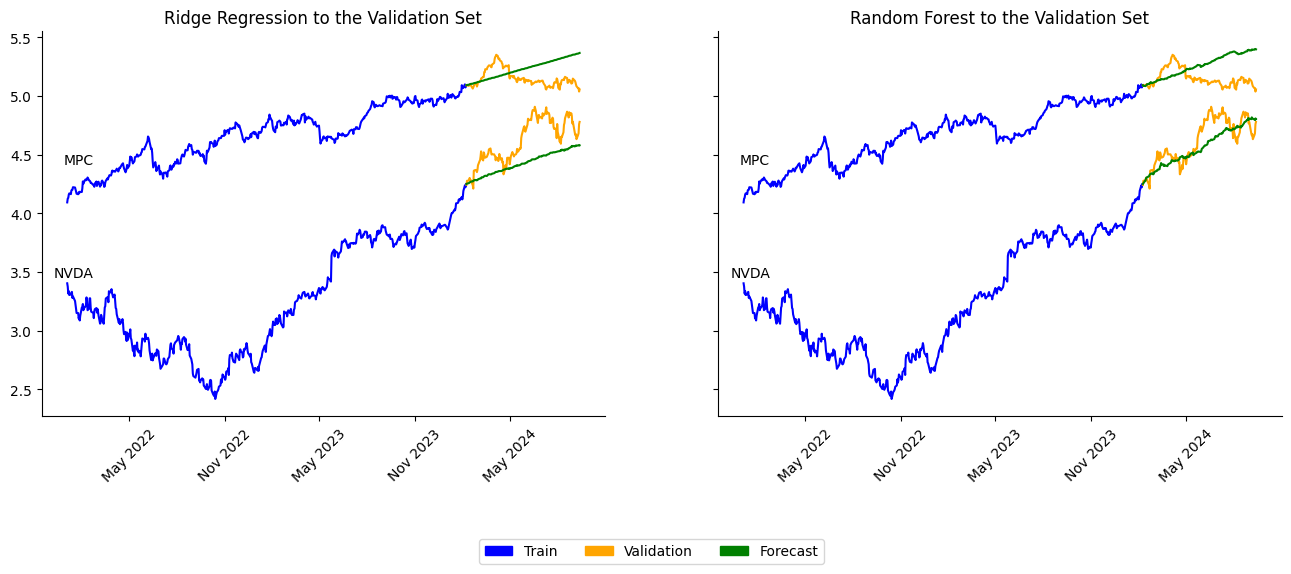

**Figure 12.** Baseline Forecasts of Log Prices Across Stocks

In [32]:
lr_preds_per_stock_df = pd.DataFrame(lr_preds_per_stock)
lr_preds_per_stock_df.index = val_df.index

rf_preds_per_stock_df = pd.DataFrame(rf_preds_per_stock)
rf_preds_per_stock_df.index = val_df.index

# Drawing time!
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)

# for each axis, plot and make it pretty
for ax in axs:
    ax.plot(train_df, color='blue', alpha=opacity_num)

    ax.plot(val_df, color='orange', alpha=opacity_num)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # major ticks each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as 'Jan 2025'
    ax.tick_params(axis='x', rotation=45)  # rotate labels
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Get the last x position for placing labels
    x_pos = ax.get_xlim()[1] * 0.951 # near the right edge
    # Top line (MPC)
    y_pos_top = train_df.iloc[-1, 0] - 0.7  # adjust column if needed
    ax.text(x_pos, y_pos_top, 'MPC', color='black', fontsize=10, ha='right', va='bottom')
    # Bottom line (NVDA)
    y_pos_bottom = train_df.iloc[-1, 1] - 0.7  # adjust column if needed
    ax.text(x_pos, y_pos_bottom, 'NVDA', color='black', fontsize=10, ha='right', va='top')


# Plot the mean
axs[0].plot(lr_preds_per_stock_df, label='Ridge Regression', color='green', alpha=opacity_num)
axs[0].set_title('Ridge Regression to the Validation Set')

# plot the naive
axs[1].plot(rf_preds_per_stock_df, label='Random Forest', color='green', alpha=opacity_num)
axs[1].set_title('Random Forest to the Validation Set')

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')


plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', bbox_to_anchor=(0.2, -0.3), ncol=3)

plt.show()

display(Markdown("**Figure 12.** Baseline Forecasts of Log Prices Across Stocks"))


## e. Methodology study of Ślusarczyk and Ślepaczuk

In addition to our current traditional models, we also implemented a hybrid ARIMA / ARIMA-GARCH procedure inspired by Algorithm 1 in Ślusarczyk & Ślepaczuk (2025). As seen from the image, we first fit an ARIMA(2,1,1) model to the historical log-returns and apply an ARCH-LM test to detect volatility clustering. The null hypothesis of this test is that the residuals exhibit no ARCH effects (i.e., they are homoscedastic). If the test indicates significant ARCH effects, we keep the ARIMA forecast but if not we estimate a GARCH(1,1) model on the ARIMA residuals and bootstrap future residuals. These simulated innovations are added to the ARIMA mean forecast, and the final prediction is the average of the simulation runs. If a model fails to converge, we fall back to the standard ARIMA forecast. 

For both stocks, the ARCH tests fail to reject the null hypothesis, indicating that the ARIMA residuals do not exhibit significant volatility clustering. Therefore, adding a GARCH component is unnecessary because a time-varying variance model is not justified. The stocks’ daily (or log) returns have roughly constant variance over the sample period, and the ARIMA model alone is sufficient to capture the patterns in the data without separately modeling volatility.

As a result, the forecasts shown in Figure 13, which display the ARIMA/ARIMA-GARCH predictions, are very similar to those in Figure 10 which showed the forecasts of ARIMA alone. The main difference is a slight increase in noise due to the ARIMA model’s $p=2$ and $q=1$ specification, but the overall trend and shape of the forecasts remain consistent with the previous figure.


In [33]:
# Dictionaries to store forecasts and methods
arima_forecasts = {}
method_used = {}

Tf = len(val_df)  # forecast horizon = validation period

# Fixed RNG for reproducibility (important!)
rng = np.random.default_rng(42)

# Forecast loop per stock
for stock in selected_stocks:
    r = train_df[stock].dropna()
    
    if len(r) < 20:
        arima_forecasts[stock] = np.zeros(Tf)
        method_used[stock] = "Skipped (not enough data)"
        continue

    # ARCH test
    try:
        stat, pval, _, _ = het_arch(r, nlags=5)
    except:
        pval = 1.0

    # Forecast
    order_by_god = (2,1,1)
    if pval < 0.05:  # reject H0 → ARIMA only
        try:
            arima_res = ARIMA(r, order=order_by_god).fit()
            arima_forecasts[stock] = arima_res.get_forecast(Tf).predicted_mean.values
            method_used[stock] = "ARIMA"
        except:
            arima_forecasts[stock] = np.zeros(Tf)
            method_used[stock] = "ARIMA (failed)"
    else:  # H0 not rejected → ARIMA-GARCH (deterministic simulation)
        try:
            arima_res = ARIMA(r, order=order_by_god).fit()
            arima_mean = arima_res.get_forecast(Tf).predicted_mean.values

            garch_mod = arch_model(arima_res.resid, p=1, q=1, mean='Zero')
            garch_res = garch_mod.fit(disp="off")

            # Deterministic simulation using fixed RNG
            sim = garch_res.simulate(
                garch_res.params,
                nobs=Tf,
                repetitions=50,
                rng=rng
            )
            sim_resid = sim["data"]

            arima_forecasts[stock] = (arima_mean[:, None] + sim_resid).mean(axis=1)
            method_used[stock] = "ARIMA-GARCH"
        except:
            try:
                fallback = ARIMA(r, order=order_by_god).fit()
                arima_forecasts[stock] = fallback.get_forecast(Tf).predicted_mean.values
                method_used[stock] = "ARIMA (fallback)"
            except:
                arima_forecasts[stock] = np.zeros(Tf)
                method_used[stock] = "Failed"

# Convert forecasts to DataFrame
arima_forecasts_df = pd.DataFrame(arima_forecasts, index=val_df.index)

# Compute metrics and append to existing performance_stock
for stock in selected_stocks:
    performance_stock[stock]['ARIMA/ARIMA-GARCH'] = ForecastingMetrics.compute_all_metrics(
        val_df[stock], arima_forecasts_df[stock]
    )

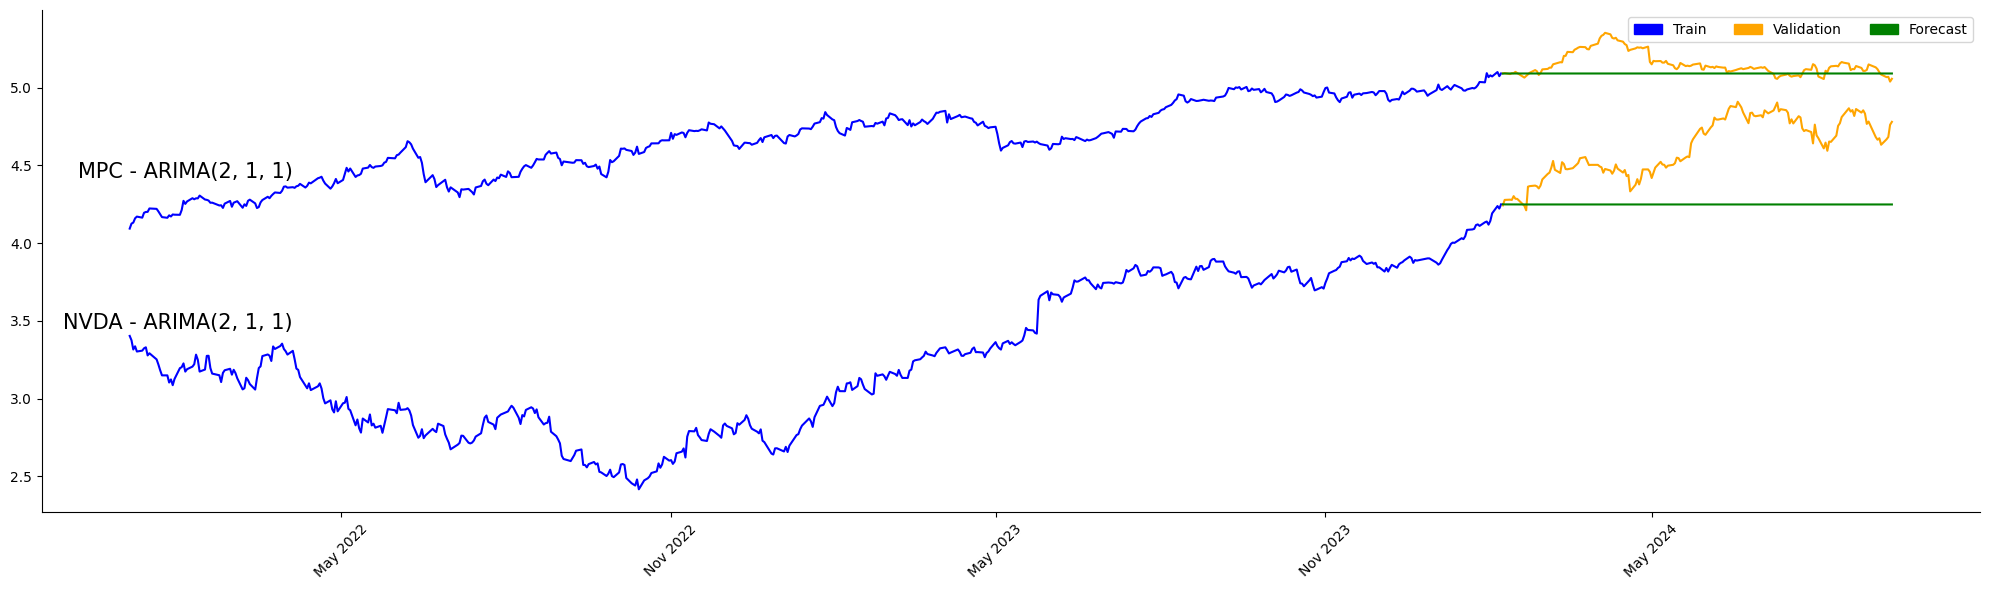

**Figure 13.** ARIMA/ARIMA-GARCH Forecasts of Log Prices Across Stocks

In [34]:
fig, ax = plt.subplots(figsize=(20, 6))


# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)

# --- arima/arima garch walk with drift forecast ---
ax.plot(arima_forecasts_df, color='green', alpha=opacity_num, label='ARIMA/GARCH Forecast')

#ax.set_title('Random Walk with Drift Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', ncol=3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Get the last x position for placing labels
x_pos = ax.get_xlim()[1] * 0.953 # near the right edge
# Top line (MPC)
y_pos_top = train_df.iloc[-1, 0] - 0.7  # adjust column if needed
ax.text(x_pos, y_pos_top, 'MPC - ARIMA(2, 1, 1)', color='black', fontsize=15, ha='right', va='bottom')
# Bottom line (NVDA)
y_pos_bottom = train_df.iloc[-1, 1] - 0.7  # adjust column if needed
ax.text(x_pos, y_pos_bottom, 'NVDA - ARIMA(2, 1, 1)', color='black', fontsize=15, ha='right', va='top')

plt.show()

display(Markdown("**Figure 13.** ARIMA/ARIMA-GARCH Forecasts of Log Prices Across Stocks"))

## f. VAR

Vector Autoregression (VAR) is a model that captures linear interdependencies among multiple time series, modeling each variable as a function of its own past values and the lagged values of other variables. This makes it useful for analyzing how shocks in one series affect others over time and for forecasting, which is appropriate for our case (Jimoh, 2023). In this analysis, we first differenced log prices to make the series stationary, so the VAR models operate on returns rather than levels. The lag order for VAR was selected based on the Akaike Information Criterion (AIC), ensuring an optimal balance between model fit and complexity. To capture relevant cross-series effects, we used “neighbor” stocks from the same sector, which is energy for MPC and technology for NVDA. 

Figure 14 plots the forecast of the the VAR model. For MPC, the VAR(1) model incorporates lagged returns of all variables, so its forecast reflects both its own past growth and the growth of its sector peers that were found in the training set. However, in the validation set, MPC’s actual returns were relatively slow, causing VAR(1) to overpredict. In contrast, NVDA has been experiencing unusually rapid growth compared to its historical average, so the VAR(0) model consistently underpredicts. Overall, the analysis shows that MPC has been experiencing lower returns relative to its sector peers, whereas NVDA has been growing faster than its historical average, illustrating how VAR can reveal differences in momentum and cross-series influence across stocks.

In [35]:
# Get the full log price DataFrame again
# We previously filtered down to specific stocks, so we need to reload all stocks here
# in order to access the related stocks for ARIMA/ARIMA-GARCH forecasts
all_log_df = np.log(yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"])
all_train_df = all_log_df.iloc[:train_end]

# We subtract one because we will difference the series for modeling
all_val_df = all_log_df.iloc[train_end - 1:val_end]
all_test_df = all_log_df.iloc[val_end - 1:]


[*********************100%***********************]  30 of 30 completed


In [36]:
log_returns_train = all_train_df.diff().dropna()
log_returns_val = all_val_df.diff().dropna()

# Dictionaries to store forecasts
var_forecasts = {}
var_methods = {}

for stock in selected_stocks:
    # Find related stocks in the same category
    related_stocks = category_stock[stock_categories[stock]]

    # Select returns for training and validation
    related_returns_train = log_returns_train[related_stocks]
    related_returns_val = log_returns_val[related_stocks]

    # Fit VAR on related returns
    model = VAR(related_returns_train)
    lag_selection = model.select_order(maxlags=5)
    best_lag = lag_selection.selected_orders['aic']
    print(f"Selected lag order (AIC) for {stock}: {best_lag}")

    var_res = model.fit(best_lag)

    # Forecast returns for validation period
    if best_lag == 0:
        # Predict mean return for all steps
        mean_return = related_returns_train.mean()
        forecast_returns = np.tile(mean_return.values, (len(related_returns_val), 1))
    else:
        forecast_returns = var_res.forecast(
            related_returns_train.values[-best_lag:], 
            steps=len(related_returns_val)
        )

    forecast_returns_df = pd.DataFrame(
        forecast_returns,
        index=related_returns_val.index,
        columns=related_returns_train.columns
    )

    # Convert forecasted returns back to log prices
    last_log_price = all_train_df[stock].iloc[-1]
    adjusted_all_val_df = all_val_df.iloc[1:]
    forecast_log_price = last_log_price + np.cumsum(forecast_returns_df[stock])

    # Save forecast
    var_forecasts[stock] = forecast_log_price

    # Save **only the target stock** forecast
    var_forecasted = forecast_returns_df[stock]
    performance_stock[stock][f'VAR ({best_lag})'] = ForecastingMetrics.compute_all_metrics(
    adjusted_all_val_df[stock], forecast_log_price
)

Selected lag order (AIC) for MPC: 1
Selected lag order (AIC) for NVDA: 0


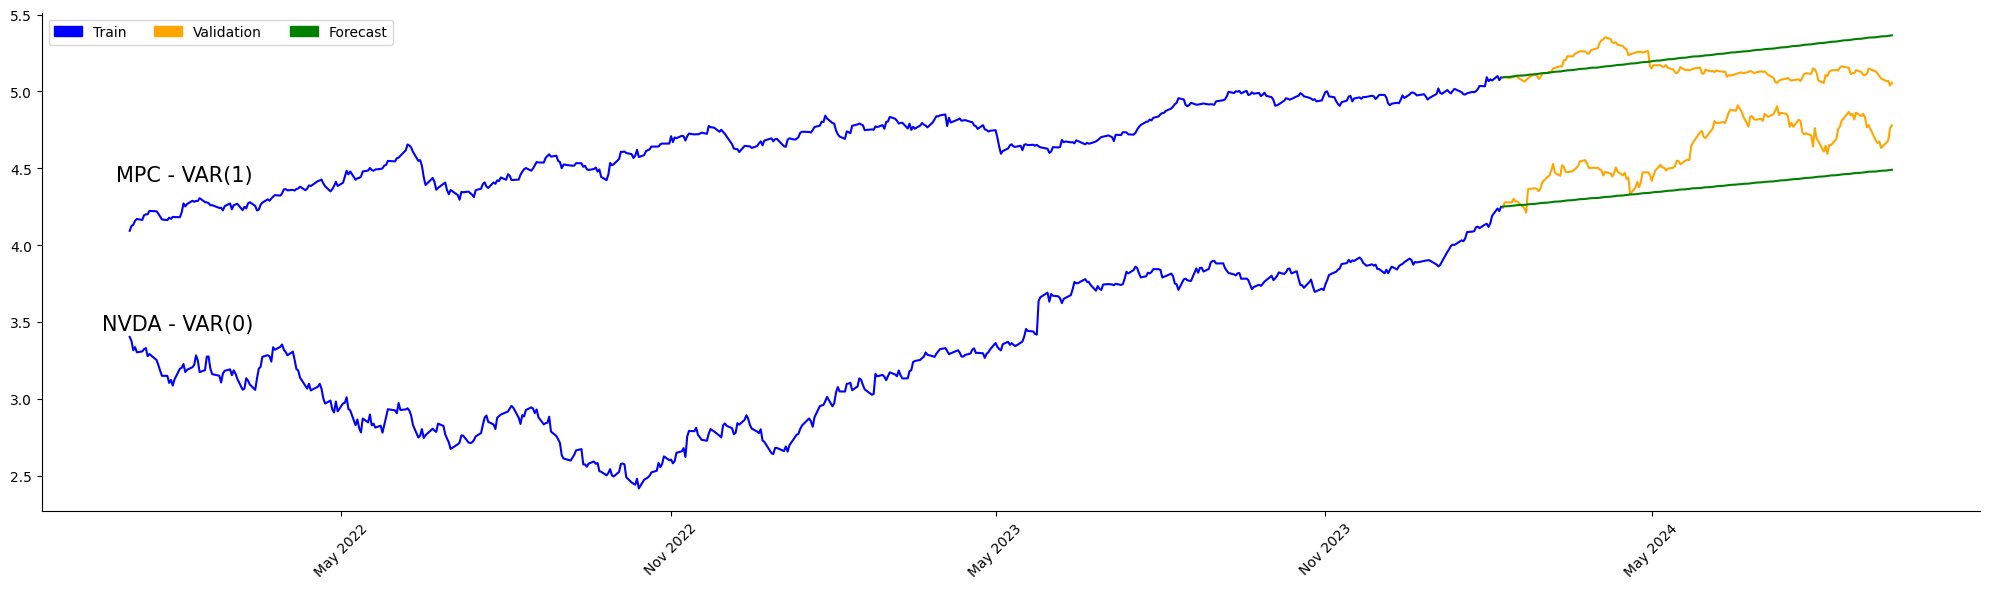

**Figure 14.** VAR Forecasts of Log Prices Across Stocks

In [37]:
fig, ax = plt.subplots(figsize=(20, 6))


# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)

# --- arima/arima garch walk with drift forecast ---
ax.plot(pd.DataFrame(var_forecasts), color='green', alpha=opacity_num, label='ARIMA/GARCH Forecast')

#ax.set_title('Random Walk with Drift Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', ncol=3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Get the last x position for placing labels
x_pos = ax.get_xlim()[1] * 0.9519 # near the right edge
# Top line (MPC)
y_pos_top = train_df.iloc[-1, 0] - 0.7  # adjust column if needed
ax.text(x_pos, y_pos_top, 'MPC - VAR(1)', color='black', fontsize=15, ha='right', va='bottom')
# Bottom line (NVDA)
y_pos_bottom = train_df.iloc[-1, 1] - 0.7  # adjust column if needed
ax.text(x_pos, y_pos_bottom, 'NVDA - VAR(0)', color='black', fontsize=15, ha='right', va='top')

plt.show()

display(Markdown("**Figure 14.** VAR Forecasts of Log Prices Across Stocks"))

In [38]:
metrics_df_selected = performance_dict_to_df(performance_stock)

# Display metrics per stock sorted by MSE (smallest to largest)
for stock in selected_stocks:
    print(f"Metrics for {stock} (sorted by MSE):")
    stock_metrics = metrics_df_selected.loc[stock].sort_values(by='MSE')
    display(stock_metrics)
    print("-" * 60)

Metrics for MPC (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Naive,0.066385,0.008824,0.093935,1.271639,1.287487,46.308723
"ARIMA(0, 1, 0)",0.066385,0.008824,0.093935,1.271639,1.287487,46.308723
ARIMA/ARIMA-GARCH,0.066621,0.008866,0.094159,1.276185,1.292120,50.335571
Seasonal Naive,0.123777,0.021508,0.146655,2.385126,2.425303,48.993290
VAR (1),0.126881,0.022232,0.149103,2.467901,2.437014,53.691277
Linear Regression,0.127984,0.022612,0.150372,2.489637,2.457837,53.691277
Random Wak with Drift,0.130874,0.023743,0.154087,2.546483,2.512108,53.691277
Random Forest,0.150340,0.031851,0.178469,2.927973,2.877582,48.322147
Mean,0.491423,0.246697,0.496686,9.522042,10.007131,46.308723


------------------------------------------------------------
Metrics for NVDA (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Random Forest,0.089433,0.013014,0.114078,1.906442,1.926991,44.966442
Linear Regression,0.190154,0.049012,0.221386,4.040650,4.151880,46.308723
Random Wak with Drift,0.244972,0.077186,0.277823,5.208630,5.385542,54.362415
VAR (0),0.244972,0.077186,0.277823,5.208630,5.385542,54.362415
Naive,0.366027,0.167392,0.409136,7.785086,8.176199,45.637585
"ARIMA(0, 1, 0)",0.366027,0.167392,0.409136,7.785086,8.176199,45.637585
ARIMA/ARIMA-GARCH,0.366710,0.167911,0.409769,7.799881,8.192258,45.637585
Seasonal Naive,0.511087,0.297947,0.545845,10.938992,11.655951,47.651009
Mean,1.355541,1.871434,1.368004,29.260727,34.340237,45.637585


------------------------------------------------------------


The table below summarizes the insights from the performance of the models for each stock and identifies the most suitable forecasting model based on the evaluation metrics. Because ARIMA(0,1,0) and the Naive model generate equivalent forecasts, we treat them as interchangeable and report results using either specification.

| **Stock** | **Findings** | **Final Model** |
|-----------|--------------|-----------------|
| **NVDA** | • Random Forest is the best model, outperforming all others across MSE, RMSE, and MAE, indicating strong nonlinear patterns in NVDA’s price movements.<br>• Linear Regression performs poorly, meaning NVDA’s high volatility isn't captured by a linear structure.<br>• ARIMA-based models fail due to NVDA’s explosive growth and structural breaks. | **Random Forest** |
| **MPC** | • Naive and ARIMA(0,1,0) produce the lowest errors, implying MPC follows a near–random walk process.<br>• VAR(1) and Linear Regression improve directional accuracy but still perform worse than Random Walk models in terms of errors.<br>• Random Forest and nonlinear models worsen performance, showing no strong nonlinear dependencies. | **ARIMA(0,1,0) or Naive** |


**Table 8:** Model Selection Summary Based on Forecasting Performance

Given that Naive and Random Forest were identified as the best-performing forecasting models for MPC and NVDA respectively (as summarized in Table 9), we now construct a consolidated training set to fit these models on the full pre-test data. After training the chosen models on the consolidated dataset, we produce forecasts over the full test period and compute the corresponding forecasting metrics. 

In [39]:
# Prepare differenced series
super_train = close_log_df[:val_end]
series = super_train.diff().dropna().reset_index(drop=True)

# Fit the model
X, y = create_xy(series['NVDA'], 
                 lookback=rf_best_per_stock['NVDA']['lookback'], 
                 horizon=1)

model = RandomForestRegressor(
    n_estimators=rf_best_per_stock['NVDA']['n_estimators'], 
    random_state=42
)
model.fit(X, y)


# Recursive predictions for the length of the test set
lookback = rf_best_per_stock['NVDA']['lookback']
test_horizon = len(test_df['NVDA'])  # how many predictions we need

# Get the last `lookback` differenced values from training
window = list(series['NVDA'][-lookback:])

recursive_preds = []

for _ in range(test_horizon):
    x_input = np.array(window[-lookback:]).reshape(1, -1)
    next_pred = model.predict(x_input)[0]

    recursive_preds.append(next_pred)

    # Append the predicted difference into the rolling window
    window.append(next_pred)

# get the log prices
last_train_price = close_log_df['NVDA'][:val_end].iloc[-1]

log_preds = []
current_log = last_train_price

for d in recursive_preds:
    current_log = current_log + d
    log_preds.append(current_log)

test_metrics = {}
test_metrics['NVDA - Random Forest'] = ForecastingMetrics.compute_all_metrics(test_df['NVDA'], log_preds)

naive_mpc = val_df.loc['2024-09-12', 'MPC'] * np.ones(len(test_df))
test_metrics['MPC - ARIMA(0, 1, 0) or Naive'] = ForecastingMetrics.compute_all_metrics(test_df['MPC'], naive_mpc)

display(pd.DataFrame(test_metrics))
display(Markdown("**Table 9.** Consolidated Model Training and Final Forecasting Evaluation"))

,NVDA - Random Forest,"MPC - ARIMA(0, 1, 0) or Naive"
MAE,0.079796,0.057456
MSE,0.009931,0.006252
RMSE,0.099654,0.079071
MAPE,1.624816,1.159336
SMAPE,1.614616,1.147605
Directional Accuracy,50.666668,56.000000


**Table 9.** Consolidated Model Training and Final Forecasting Evaluation

# VI. Re-optimize the portfolio using the Forecasted Prices

Traditional Markowitz portfolio optimization is static because it relies solely on historical averages and covariances. We enhance the responsiveness of the portfolio to changing market conditions by by incorporating forecasted log prices into mean-variance optimization. This extension draws motivation from Ślusarczyk and Ślepaczuk (2025) and Shi (2025), who demonstrate how integrating predictive signals can improve the adaptability of classical portfolio models.

We introduce a forward-looking component by complementing the historical mean returns and covariance with forecasted returns and covariances derived from the best-performing predictive models identified in Table 8. Specifically, for each asset $j$, we append a 120-day return sequence composed of the most recent 60 actual log returns and the next 60 forecasted log returns from the validation set. In the original Markowitz setup, the expected returns and covariance matrix were computed solely from the training set. By appending the validation set forecasts, we extend the input series to include forward-looking information while keeping the classical mean–variance optimization framework unchanged. The expected return vector is then computed as:

$$
\mu^* =
\begin{bmatrix}
\mu_1^* \\
\vdots \\
\mu_n^*
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{T} \sum_{i=1}^T r_{t-i,1}^* \\
\vdots \\
\frac{1}{T} \sum_{i=1}^T r_{t-i,n}^*
\end{bmatrix},
$$

where where the average is taken over the actual log returns from the training set and the forecasted returns from the validation set. Similarly, the variance–covariance matrix of the combined series training and forecasted is:

$$
\Sigma^* =
\begin{bmatrix}
\sigma_{1}^{*2} & \cdots & \sigma_{1n}^* \\
\vdots & \ddots & \vdots \\
\sigma_{n1}^* & \cdots & \sigma_{n}^{*2}
\end{bmatrix},
$$

where $\sigma_i^{*2}$ is the variance of the actual and forecasted log returns of asset $i$, and $\sigma_{ij}^*$ is the empirical covariance between assets $i$ and $j$ over the combined sequence.  

By appending forecasted returns from the validation set to the recent historical returns, the resulting expected return vector $\mu^*$ and covariance matrix $\Sigma^*$ remain compatible with the classical mean–variance optimization framework while incorporating forward-looking information. This approach allows the portfolio to better anticipate short-term market dynamics and improves the adaptability of the optimization to near-future conditions.

In Figure 15, we present the predicted returns and volatilities of various portfolio allocations according to the Markowitz model. Notably, the equal-weight portfolio, which was previously sub-optimal, now lies on the efficient frontier. Conversely, the weights from the previous static portfolio are now sub-optimal since it is not on the efficient frontier. This reflects the strong growth of NVIDIA observed in the validation set but not in the training set. This highlights a key limitation of the Markowitz framework where it assumes that historical returns remain constant over time, which may not hold in practice. We also observe that the new Markowitz portfolio is expected to yield lower returns than the equal-weight portfolio, but with reduced volatility. Ultimately, the choice between these portfolios depends on the investor's risk preference. Risk-averse investors may prefer the Markowitz allocation, whereas those willing to take on more risk may favor the equal-weight portfolio. 


In [44]:
# Extract the historical returns for the specific stock
mpc_hist = train_df['MPC']
nvda_hist = train_df['NVDA']


# Get the forecasted series
mpc_forecast = arima_forecasts_df['MPC']
nvda_forecast = rf_preds_per_stock_df['NVDA']

# Append forecasts to historical returns
mpc_combined = pd.concat([mpc_hist, mpc_forecast], ignore_index=True)
nvda_combined = pd.concat([nvda_hist, nvda_forecast], ignore_index=True)

# Combine into a single DataFrame
combined_df = pd.DataFrame({
    'MPC': mpc_combined,
    'NVDA': nvda_combined
})

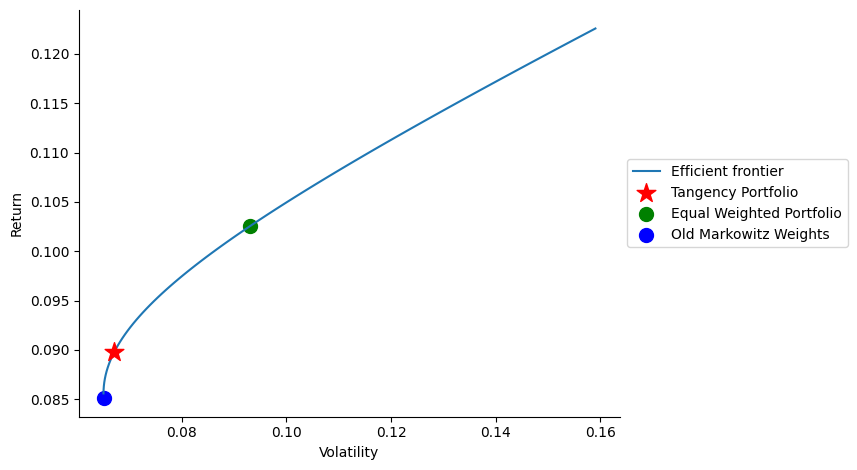

**Figure 15.** Scatterplot of Portfolio Volatility vs Expected Return with New Portfolio Weights

In [45]:
mu = mean_historical_return(combined_df, log_returns=True)
Sigma = CovarianceShrinkage(combined_df, log_returns=True).ledoit_wolf()


# Compute tangency portfolio
ef_tan_new = EfficientFrontier(mu, Sigma)
tangency_portfolio = ef_tan_new.max_sharpe(risk_free_rate=0.02)
new_weights_df = pd.DataFrame(
    [(stock, weight) for stock, weight in ef_tan_new.clean_weights().items() if weight > 0],
    columns=['Stock', 'Weight']
)

exp_return, vol, sharpe = ef_tan_new.portfolio_performance(risk_free_rate=0.02)

# Create another EF instance just for plotting
ef_plot = EfficientFrontier(mu, Sigma)
plotting.plot_efficient_frontier(ef_plot, show_assets=False)
plt.scatter(vol, exp_return, marker="*", color="r", s=200, label="Tangency Portfolio", zorder=10)

# plot the equal weighted portfolio
num_stocks = combined_df.shape[1]
equal_weight = np.ones(num_stocks) / num_stocks
mu_equal = mu @ equal_weight
sigma_equal = np.sqrt(equal_weight.T @ Sigma @ equal_weight)

# plot the old markowitz weights
old_weights = {stock: weight for stock, weight in ef_tan.clean_weights().items() if weight > 0}
#list(old_weights.items())
num_stocks = close_historical_df.shape[1]
old_weights_array = np.array(list(old_weights.values()))
mu_old = mu @ old_weights_array
sigma_old = np.sqrt(old_weights_array.T @ Sigma @ old_weights_array)

# Equal-weighted portfolio
plt.scatter(sigma_equal, mu_equal, marker='o', color='green', s=100, label='Equal Weighted Portfolio')

# plot old weight
plt.scatter(sigma_old, mu_old, marker='o', color='blue', s=100, label='Old Markowitz Weights')

plt.legend(loc='upper left', bbox_to_anchor=(1, 0.65))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()
display(Markdown('**Figure 15.** Scatterplot of Portfolio Volatility vs Expected Return with New Portfolio Weights'))


However, what we have done right now is just the theory of Modern Portfolio Theory. We haven't yet actually tested it out in practice. So let's do the science in data science and do some empirical testing. Table 9 indicates that the theoretical expectations align with observed performance since the Equal Weight Portfolio has the highest return of 32% but also the highest volatility of 1.45%. In contrast to this, Dynamic Markowitz portfolio achieves a balance between return and risk since while it has a lower return of 24%, it also achieved a lower volatility of 1.00%. This suggests that the principles of Modern Portfolio Theory provide a useful framework for portfolio construction, though practical implementation and testing remain essential.

In [54]:
capital = 10_000

# Backtests
mpc_backtest = Backtest(starting_capital=capital)
nvda_backtest = Backtest(starting_capital=capital)

mpc_backtest.run_strategy(np.exp(np.array(val_df['MPC'])), np.array(np.exp(mpc_forecast)))
nvda_backtest.run_strategy(np.exp(np.array(val_df['NVDA'])), np.array(np.exp(nvda_forecast)))

# Define scenarios: name to allocation
scenarios = {
    'Equal Weight': 'equal',              
    'Static Markowitz': old_weights,      
    'Dynamic Markowitz': dict(ef_tan_new.clean_weights()),
}

portfolio_reports = {}

for scenario_name, allocation in scenarios.items():
    portfolio = PortfolioEvaluator(starting_capital=capital, allocation=allocation)
    portfolio.add_stock('MPC', mpc_backtest, model_name='ARIMA(0, 1, 0)')
    portfolio.add_stock('NVDA', nvda_backtest, model_name='Random Forest')
    
    # Remove the portfolio values and num_stocs
    results_filtered = portfolio.compute_portfolio_performance()
    results_filtered.pop('portfolio_values', None)
    results_filtered.pop('num_stocks', None)

    portfolio_reports[scenario_name] = results_filtered

display(pd.DataFrame(portfolio_reports).round(4))
display(Markdown("**Table 9.** Trading Metrics Across the Different Portfolios"))


,Equal Weight,Static Markowitz,Dynamic Markowitz
initial_capital,10000.0000,10000.0000,10000.0000
final_value,13211.9270,11514.5216,11969.4301
total_return_%,32.1193,15.1452,19.6943
profit_$,3211.9270,1514.5216,1969.4301
sharpe_ratio,0.1306,0.1371,0.1513
max_drawdown_%,-7.8986,-2.8387,-3.1650
volatility_%,1.4513,0.6478,0.7648


**Table 9.** Trading Metrics Across the Different Portfolios

# VII. Limitations and Recommendations

**1. Limitations**

This study has several notable limitations from both the finance-related and technical perspectives.  

**Finance-Related Limitations:**
1. The Markowitz framework depends heavily on the historical period used for estimation. It assumes that expected returns, volatilities, and covariances remain stable over time. In practice, markets evolve, and companies change their structure over time. This means that if the training period reflects unusually slow or fast performance, the resulting optimized portfolio may not reflect current and future conditions. Although we used forecasts to extend the model beyond the training window, they cannot fully remove the dependence on the initial period.

2. We measured volatility using standard deviation, which treats all variability as equally undesirable. This approach does not distinguish between harmful downside movement and favorable upside movement. Consequently, assets with large positive gains may appear riskier than they are from an investor’s perspective.

3. The classical Markowitz framework does not account for transaction costs or portfolio turnover. Portfolios that require extreme weights or frequent rebalancing could face substantial real-world costs that reduce net returns. Even though the dynamic strategy in this study rebalances less often, the limitation of ignoring trading frictions remains, and we did not account for this cost.

**Technical Limitations:**
1. Most of our forecasting models treat stocks independently. Only the VAR model considers interactions across assets, which means that many cross-stock influences, such as industry cycles or macroeconomic linkages, are only partially captured. This restricts our ability to fully understand how shocks in one asset may propagate to others.



**2. Recommendations**
Based on our study, we recommend several improvements, specifically on the financial-related aspects, for future research to enhance the practical applicability and robustness of portfolio optimization and forecasting strategies.

**Finance-related improvements:**

1. We suggest adopting a hybrid investment decision process that combines model-based forecasting with practical trading considerations. Our findings indicate that even with just two stocks, there is no single forecasting model that is consistently the best. MPC and NVDA exhibit unique behaviors, which implies that tailored models are necessary. Forecasts should therefore be treated as directional guidance rather than exact price predictions.
2. Volatility measurement should be enhanced beyond standard deviation. Incorporating downside risk metrics, such as Value at Risk or Conditional Value at Risk, can distinguish harmful downside movements from beneficial upside gains, providing a more realistic representation of investor risk.
3. Transaction costs, turnover, and rebalancing frictions should be included to improve the realism of the strategy. While our dynamic approach reduces frequent rebalancing, adding execution rules such as turnover limits, position caps, and explicit transaction cost modeling will better align the strategy with real trading conditions.


**Technical improvements:**

1. Most forecasting models in this study treat stocks independently. Although we did look into and use VAR models, we could delve deeper into their potential. Expanding VAR structures or using machine learning architectures could better capture cross-asset interactions and more accurately reflect industry cycles, macroeconomic linkages, and the propagation of shocks between assets.

# VIII. Conclusion

In creating a successful entry for White Stone’s hackathon, this report was able to address the challenge of creating a stock portfolio strategy that balances both forecasting accuracy and portfolio profitability. The team used a modified Markowitz MPT framework that incorporated forecasted returns into mean-variance optimization and a time-series momentum overlay to create a portfolio. 

This portfolio is focused heavily on the stocks NVDA and MPC, reflecting cross-sector diversity so that it can balance risk and return. Using MSE as the primary forecasting accuracy metric, Random Forest captured NVDA’s dynamic nature with an MSE of 0.00052 and a SMAPE of 1.64 percent, while the simpler ARIMA(0,1,0) sufficiently described the more stable MPC stock with an MSE of 0.00031 and a SMAPE of 1.15 percent. Because these models were trained on log prices, the MSE values appear very small, so we also provide SMAPE to provide a sense of scale and also easier interpretation of real-scale forecasting accuracy.

Across the three strategies of Equal Weight, Static Markowitz, and Dynamic Markowitz, the Dynamic Markowitz portfolio performed best in terms of risk-adjusted return. While its absolute return was lower than that of the Equal Weight strategy, it achieved the highest Sharpe ratio of 0.1513, indicating that when adjusted for risk, it offered the most efficient and balanced performance among the three approaches.

Overall, this study demonstrates the practical benefits of combining mean-variance optimization and model-based forecasting to create portfolios that are responsive to market dynamics while managing risk effectively.
